In [1231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [1232]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1233]:
missing_df = pd.read_csv('/content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/student_data/Group044/Group_044_missing_data.csv')

In [1234]:
dirty_df = pd.read_csv('/content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/student_data/Group044/Group_044_dirty_data.csv')

In [1235]:
outlier_df = pd.read_csv('/content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/student_data/Group044/Group_044_outlier_data.csv')

In [1236]:
warehouse_df = pd.read_csv('/content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/warehouses.csv')

# Missing Data Handling

## EDA analysis on missing data

In [1237]:
# Show first 5 rows of dataset

missing_df.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD101108,ID0577456440,2019-05-20,Bakers,"[('Candle Inferno', 1), ('Alcon 10', 1)]",9380.0,81.52,-37.823146,144.988553,10,8523.52,Autumn,True,1.5772,convoy 2 yes i like my convoy. a few more surf...,1.0
1,ORD116859,ID0233255225,2019-11-24,NaN,"[('Alcon 10', 1), ('Thunder line', 2)]",13310.0,83.04,-37.798832,144.983084,25,10065.54,Spring,False,NaN,so happy with it so far this is the most under...,1.0
2,ORD162115,ID0248746945,2019-03-03,Bakers,"[('Candle Inferno', 1), ('Lucent 330S', 2), ('...",9700.0,66.68,-37.823082,144.991595,15,8311.68,Autumn,False,1.4914,highly recommend ! this phone is perfect. i lo...,1.0
3,ORD460515,ID1492150953,2019-11-18,Thompson,"[('Alcon 10', 2), ('iAssist Line', 1), ('Thund...",24915.0,85.01,-37.814543,144.952047,15,21262.76,Spring,True,0.4847,headphone missing headphone is not available i...,0.0
4,ORD173206,ID0746912558,2019-03-23,Nickolson,"[('iAssist Line', 2), ('Lucent 330S', 2)]",6910.0,81.87,-37.824803,144.982821,10,6300.87,Autumn,True,1.3561,best ❤ phone my son loves his new phone. he up...,1.0


In [1238]:
# Show total rows and columns of dataset

missing_df.shape

(500, 16)

In [1239]:
missing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       500 non-null    object 
 1   customer_id                    500 non-null    object 
 2   date                           500 non-null    object 
 3   nearest_warehouse              445 non-null    object 
 4   shopping_cart                  500 non-null    object 
 5   order_price                    485 non-null    float64
 6   delivery_charges               460 non-null    float64
 7   customer_lat                   500 non-null    float64
 8   customer_long                  500 non-null    float64
 9   coupon_discount                500 non-null    int64  
 10  order_total                    485 non-null    float64
 11  season                         500 non-null    object 
 12  is_expedited_delivery          500 non-null    boo

In [1240]:
# Show all the column names of the dataset
missing_df.columns

Index(['order_id', 'customer_id', 'date', 'nearest_warehouse', 'shopping_cart',
       'order_price', 'delivery_charges', 'customer_lat', 'customer_long',
       'coupon_discount', 'order_total', 'season', 'is_expedited_delivery',
       'distance_to_nearest_warehouse', 'latest_customer_review',
       'is_happy_customer'],
      dtype='object')

In [1241]:
# Show data types of each column
missing_df.dtypes

,0
order_id,object
customer_id,object
date,object
nearest_warehouse,object
shopping_cart,object
order_price,float64
delivery_charges,float64
customer_lat,float64
customer_long,float64
coupon_discount,int64


In [1242]:
# Checking for missing values
missing_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,55
shopping_cart,0
order_price,15
delivery_charges,40
customer_lat,0
customer_long,0
coupon_discount,0


In [1243]:
# Checking if any duplicate columns
missing_df.duplicated().sum()

np.int64(0)

In [1244]:
missing_df.describe()

,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,distance_to_nearest_warehouse,is_happy_customer
count,485.000000,460.000000,500.000000,500.000000,500.000000,485.000000,469.000000,460.000000
mean,14002.628866,77.220717,-37.812645,144.967790,10.350000,12612.375381,1.060524,0.767391
std,8223.553180,14.237657,0.007732,0.021538,8.370641,7498.827108,0.513608,0.422955
min,580.000000,47.630000,-37.833333,144.918101,0.000000,558.520000,0.135000,0.000000
25%,7760.000000,66.667500,-37.819041,144.952527,5.000000,6877.010000,0.671100,1.000000
50%,12485.000000,76.395000,-37.812989,144.965480,10.000000,10773.470000,1.015000,1.000000
75%,19400.000000,84.100000,-37.806637,144.983484,15.000000,17508.210000,1.398000,1.000000
max,39750.000000,115.690000,-37.791485,145.019431,25.000000,39826.540000,2.850200,1.000000


In [1245]:
missing_df.describe(include='object')

,order_id,customer_id,date,nearest_warehouse,shopping_cart,season,latest_customer_review
count,500,500,500,445,500,500,500
unique,500,497,265,3,460,4,500
top,ORD454621,ID0711334313,2019-11-18,Thompson,"[('Candle Inferno', 1), ('pearTV', 2)]",Spring,five stars excellent device after using it for...
freq,1,2,6,175,4,151,1


To assess data completeness, .info() and .isna().sum() were used to identify missing values across all columns. The dataset contains 500 records and 16 features. Several columns had missing values, most notably nearest_warehouse (55), delivery_charges (40), is_happy_customer (40), distance_to_nearest_warehouse (31), order_price (15), and order_total (15). Descriptive statistics were generated to understand the distribution of both numerical and categorical data before deciding on suitable imputation strategies.

This analysis established a clear view of where data gaps exist, their magnitude, and the types of variables affected, providing a solid foundation for the next step, which was deciding whether to impute or remove missing entries based on their importance and proportion.

In [1246]:
# Display frequency counts for key categorical variables to understand their distribution
# This helps identify class imbalance or rare categories in columns like season, delivery type, customer satisfaction, and nearest warehouse

missing_df["season"].value_counts()

,count
season,
Spring,151
Winter,131
Autumn,114
Summer,104


In [1247]:
missing_df["is_expedited_delivery"].value_counts()

,count
is_expedited_delivery,
False,256
True,244


In [1248]:
missing_df["is_happy_customer"].value_counts()

,count
is_happy_customer,
1.0,353
0.0,107


In [1249]:
missing_df["nearest_warehouse"].value_counts()

,count
nearest_warehouse,
Thompson,175
Nickolson,159
Bakers,111


To better understand the distribution of categorical data and identify potential biases, value counts were computed for variables such as season, is_expedited_delivery, is_happy_customer, and nearest_warehouse. The results show that Spring (151) and Winter (131) orders are most common, while Summer (104) is least frequent. Delivery type is nearly balanced with 244 expedited and 256 standard deliveries, suggesting no delivery-type bias. The majority of customers (353) reported being happy with their purchase, compared to 107 unhappy customers. Additionally, Thompson (175) was the most frequently used warehouse, followed by Nickolson (159) and Bakers (111).

This step helped identify dominant categories and ensured categorical variables were well understood before handling missing values and performing further preprocessing.

<Axes: ylabel='order_price'>

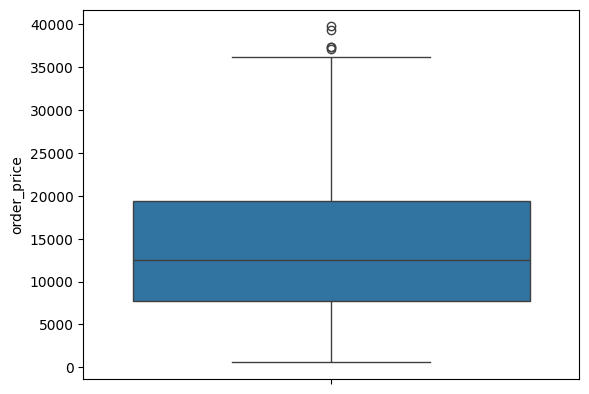

In [1250]:
# Visualise the distribution and outliers in order_price
sns.boxplot(y="order_price", data=missing_df)

<Axes: xlabel='nearest_warehouse', ylabel='delivery_charges'>

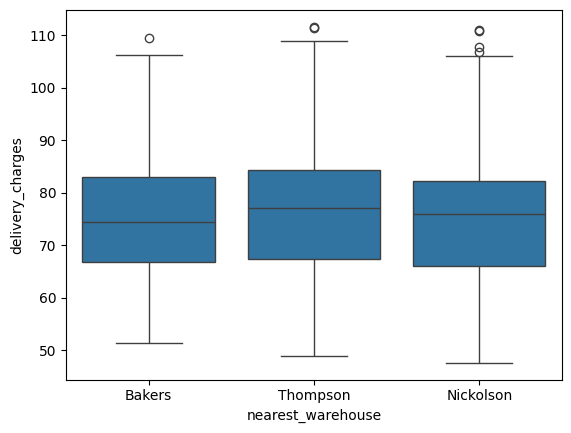

In [1251]:
# Compare delivery_charges across different nearest warehouses
sns.boxplot(y="delivery_charges", x="nearest_warehouse", data=missing_df)

<Axes: xlabel='nearest_warehouse', ylabel='distance_to_nearest_warehouse'>

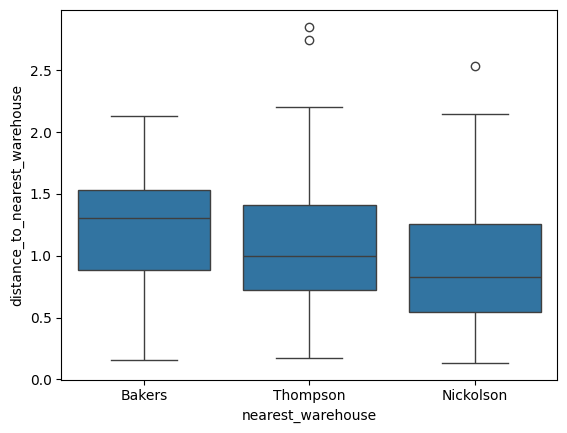

In [1252]:
# Examine how distance_to_nearest_warehouse varies by warehouse location
sns.boxplot(y="distance_to_nearest_warehouse", x="nearest_warehouse", data=missing_df)

<Axes: xlabel='is_happy_customer'>

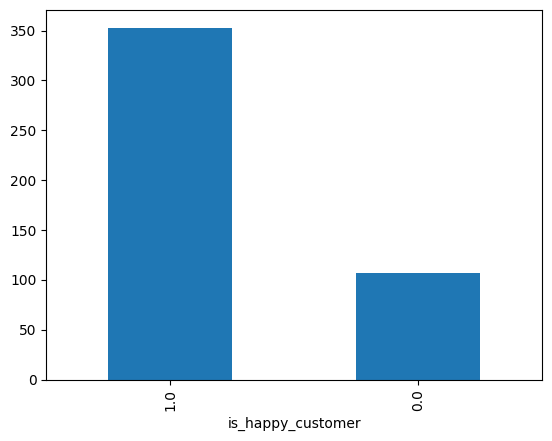

In [1253]:
# Plot bar chart to show proportion of happy vs unhappy customers
missing_df["is_happy_customer"].value_counts().plot(kind="bar")

Boxplots were used to examine the distribution and potential outliers in order_price, delivery_charges, and distance_to_nearest_warehouse, while a bar plot was used to visualize customer satisfaction.

The order_price boxplot shows a moderately right-skewed distribution with a few high-value outliers above 35,000, suggesting some premium orders. delivery_charges, grouped by nearest_warehouse, show similar medians across warehouses, with slight variation, Thompson having marginally higher charges on average. The distance_to_nearest_warehouse plot reveals that Nickolson generally serves closer customers, while Bakers covers longer distances. Finally, the is_happy_customer bar plot indicates that the majority of customers are satisfied, reflecting a positive customer experience overall.

This visual exploration helped identify data variability, detect outliers, and understand the relationships between warehouse operations, pricing, and customer satisfaction.

## 1. Fixing missing values in nearest_warehouse ##

In [1254]:
# Define a Haversine function to calculate great-circle distance between two coordinates (in km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6378  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [1255]:
# Find the nearest warehouse to a given customer location using Haversine distance
def find_nearest_warehouse(lat, lon, warehouses):
    distances = warehouses.apply(
        lambda w: haversine(lat, lon, w['lat'], w['lon']), axis=1
    )
    nearest_idx = distances.idxmin()
    return warehouses.loc[nearest_idx, 'names']  # adjust if column name differs

In [1256]:
# Identify and fill missing nearest_warehouse values based on customer coordinates
mask_missing = missing_df['nearest_warehouse'].isna()
missing_df.loc[mask_missing, 'nearest_warehouse'] = missing_df.loc[mask_missing].apply(
    lambda row: find_nearest_warehouse(row['customer_lat'], row['customer_long'], warehouse_df),
    axis=1
)

In [1257]:
# Verify that all missing nearest_warehouse values have been filled
missing_df['nearest_warehouse'].isna().sum()

np.int64(0)

In [1258]:
# Check dataset dimensions
missing_df.shape

(500, 16)

In [1259]:
# Check dataset dimensions and missing values across all columns
missing_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,15
delivery_charges,40
customer_lat,0
customer_long,0
coupon_discount,0


The missing nearest_warehouse values were imputed using a distance-based approach. A haversine() function was implemented to calculate the great-circle distance (in kilometers) between a customer’s latitude and longitude coordinates and each warehouse’s location. Then, the helper function find_nearest_warehouse() identified the closest warehouse for each customer by selecting the warehouse with the smallest calculated distance.

This method ensures that missing warehouse values are filled logically and geographically rather than randomly or by frequency. After imputation, all missing entries in nearest_warehouse were successfully resolved (0 remaining nulls), improving the dataset’s integrity for further analysis.

## 2.& 3. Fixing missing values in shopping_cart and order_price


In [1260]:
# Parse shopping_cart column from string to list of tuples
def parse_cart(cell):
  try:
    return ast.literal_eval(cell) if isinstance(cell, str) else cell
  except Exception:
    return []

In [1261]:
# Apply parsing function to create a new column with structured cart data
missing_df["parsed_cart"] = missing_df["shopping_cart"].apply(parse_cart)

In [1262]:
# Extract unique item names from all carts and assign index positions
items = sorted({item for cart in missing_df["parsed_cart"] for (item, qty) in cart})
item_to_idx = {item: i for i, item in enumerate(items)}

In [1263]:
item_to_idx

{'Alcon 10': 0,
 'Candle Inferno': 1,
 'Lucent 330S': 2,
 'Olivia x460': 3,
 'Thunder line': 4,
 'Toshika 750': 5,
 'Universe Note': 6,
 'iAssist Line': 7,
 'iStream': 8,
 'pearTV': 9}

In [1264]:
missing_df["parsed_cart"]

,parsed_cart
0,"[(Candle Inferno, 1), (Alcon 10, 1)]"
1,"[(Alcon 10, 1), (Thunder line, 2)]"
2,"[(Candle Inferno, 1), (Lucent 330S, 2), (Thund..."
3,"[(Alcon 10, 2), (iAssist Line, 1), (Thunder li..."
4,"[(iAssist Line, 2), (Lucent 330S, 2)]"
...,...
495,"[(iAssist Line, 1), (Lucent 330S, 2), (Univers..."
496,"[(Lucent 330S, 1), (iStream, 2), (Thunder line..."
497,"[(Universe Note, 1), (Alcon 10, 2), (iAssist L..."
498,"[(Olivia x460, 1), (pearTV, 1), (Lucent 330S, ..."


In [1265]:
#Build feature matrix (X) and target vector (y) for known order_price entries
mask_known = missing_df["order_price"].notna()
X_list, y_list = [], []

for idx, row in missing_df[mask_known].iterrows():
    vec = np.zeros(len(items))
    for (item, qty) in row["parsed_cart"]:
        vec[item_to_idx[item]] += qty
    X_list.append(vec)
    y_list.append(row["order_price"])

X = np.array(X_list)
y = np.array(y_list)

In [1266]:
print(X)

[[1. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 2. ... 0. 0. 0.]
 ...
 [2. 0. 0. ... 2. 0. 0.]
 [0. 2. 2. ... 0. 0. 1.]
 [2. 0. 1. ... 0. 1. 0.]]


In [1267]:
print(y)

[ 9380. 13310.  9700. 24915.  6910. 11530. 13880.  2760.  1660.  2330.
 18200.  8950.  4675.  6910.  5460. 20080.  7200.  9810. 17840. 17590.
 13310.  6890. 18815. 26480. 14320. 17405. 21090.  3710.  2480.  7170.
  5545. 18020.  2525.  5635.  8190.  6810. 13400.  9250.  9000. 23160.
 20125.  4620.  2955. 10820.  9955. 21350.   730. 37150. 33130. 26030.
 14320.  4675. 28070.  7330.  2085.  9630. 18970. 22725. 11860. 12335.
 12770. 13310. 31430. 12830. 13510.  9630.  6780.  5585.  4880.  4510.
  5695. 25710.  3685. 21600.  6585. 30520. 13050.  6770.  8810.  9080.
 24305. 20360.  6460. 17240.  9360. 13625. 28120. 29550. 13310. 19580.
 15850. 10760.  3320. 16300. 11015.  7760. 13465. 19430. 25945.  2750.
 39750. 21430. 13090.  8540.  3750. 19770. 21160. 28210. 16110. 16260.
  8680. 18150.  6610.  9350. 17700. 10330.  6460. 13270. 12120. 17580.
 16180. 15380.  2455. 10295. 11260.  1960.  7510.  8760.  5590. 20785.
 12005.  7760. 11270.  9040. 11295.  7705.  5550.  4910. 10630.  8790.
  9500

In [1268]:
# Estimate unit prices using least squares regression
unit_prices = np.linalg.lstsq(X, y, rcond=None)[0]

In [1269]:
# Create dictionary mapping each item to its estimated unit price
unit_price_map = {item: price for item, price in zip(items, unit_prices)}
print("Learned unit prices:")
for k,v in unit_price_map.items():
    print(f"{k}: {v:.2f}")

Learned unit prices:
Alcon 10: 8950.00
Candle Inferno: 430.00
Lucent 330S: 1230.00
Olivia x460: 1225.00
Thunder line: 2180.00
Toshika 750: 4320.00
Universe Note: 3450.00
iAssist Line: 2225.00
iStream: 150.00
pearTV: 6310.00


In [1270]:
# Fill missing order_price values using learned unit prices
mask_missing = missing_df["order_price"].isna()
for idx, row in missing_df[mask_missing].iterrows():
    total = 0
    for (item, qty) in row["parsed_cart"]:
        if item in unit_price_map:
            total += unit_price_map[item] * qty
        else:
            total = np.nan  # if an unseen item, leave as NaN
            break
    missing_df.at[idx, "order_price"] = total

In [1271]:
# Verify that all missing order_price values have been filled
missing_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,0
delivery_charges,40
customer_lat,0
customer_long,0
coupon_discount,0


The shopping_cart column originally contained string representations of lists, making it difficult to extract product and quantity information. To address this, a parsing function (parse_cart) was created to safely convert each string into a list of item–quantity tuples. This allowed the contents of each customer’s cart to be structured in a usable format under a new column parsed_cart.

Next, the unit prices of individual products were estimated using a linear least squares regression approach. A matrix (X) was constructed where each row represented the quantities of all items in an order, and the corresponding y vector contained known order prices. Solving the system using np.linalg.lstsq() produced a unit price for each product.

Using these learned unit prices, the missing order_price values were then imputed by summing the estimated cost of each product in the customer’s parsed cart. This method provides a data-driven and interpretable imputation rather than relying on arbitrary averages.

Finally, verification with missing_df.isna().sum() confirmed that all missing values in both shopping_cart and order_price were successfully resolved.

## 4.& 5. Fixing missing values in delivery_charges and order_total

In [1272]:
# Prepare input features for regression model
def prep_features(df: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame(index=df.index)

    # Base numeric and binary features
    X["distance"]  = pd.to_numeric(df["distance_to_nearest_warehouse"], errors="coerce")
    X["expedited"] = df["is_expedited_delivery"].astype(bool).astype(int)
    X["happy"]     = df["is_happy_customer"].astype(bool).astype(int)

    # One-hot encoding season column (drop first to avoid multicollinearity)
    seasons = pd.get_dummies(df["season"], prefix="season", drop_first=True)
    X = pd.concat([X, seasons], axis=1)

    # Create interaction terms to allow season-specific effects
    for col in seasons.columns:
        X[f"{col}__distance"]  = seasons[col] * X["distance"]
        X[f"{col}__expedited"] = seasons[col] * X["expedited"]
        X[f"{col}__happy"]     = seasons[col] * X["happy"]

    # Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

In [1273]:
# Select rows with complete data for training
mask_train = (
    missing_df["delivery_charges"].notna()
    & missing_df["distance_to_nearest_warehouse"].notna()
    & missing_df["is_expedited_delivery"].notna()
    & missing_df["is_happy_customer"].notna()
    & missing_df["season"].notna()
)

# Prepare training data and target
X_train = prep_features(missing_df.loc[mask_train].copy())
y_train = missing_df.loc[mask_train, "delivery_charges"].astype(float)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train linear regression model to predict delivery_charges
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate model performance
r2 = r2_score(y_train, model.predict(X_train))
print(f"R²: {r2:.4f}")

R²: 0.9948


In [1274]:
# Predict and fill missing delivery_charges
mask_pred = missing_df["delivery_charges"].isna()
if mask_pred.any():
    X_pred = prep_features(missing_df.loc[mask_pred])
    missing_df.loc[mask_pred, "delivery_charges"] = model.predict(X_pred)

In [1275]:
missing_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,0
delivery_charges,0
customer_lat,0
customer_long,0
coupon_discount,0


In [1276]:
missing_df.shape

(500, 17)

In [1277]:
# Recalculate order_total for missing values based on known fields
mask_total = missing_df["order_total"].isna() & missing_df["order_price"].notna() & missing_df["delivery_charges"].notna()

if mask_total.any():
    missing_df.loc[mask_total, "order_total"] = (
        missing_df.loc[mask_total, "order_price"] * (1 - (missing_df.loc[mask_total, "coupon_discount"].fillna(0) / 100.0))
        + missing_df.loc[mask_total, "delivery_charges"]
    )

In [1278]:
# Confirm final dataset shape and no remaining missing values
missing_df.shape

(500, 17)

In [1279]:
missing_df.loc[27, ]

,27
order_id,ORD262200
customer_id,ID1985549819
date,2019-08-13
nearest_warehouse,Nickolson
shopping_cart,"[('pearTV', 2), ('Thunder line', 1), ('Alcon 1..."
order_price,23750.0
delivery_charges,84.59
customer_lat,-37.800767
customer_long,144.966869
coupon_discount,15


To address missing values in the delivery_charges column, a supervised learning approach was applied using a multiple linear regression model. This model estimated delivery costs based on relevant operational and behavioral factors rather than relying on simple averages or assumptions.

A function, prep_features(), was first created to prepare input variables for modelling. It included key predictors such as:

* distance_to_nearest_warehouse: the most direct determinant of delivery cost

* is_expedited_delivery: indicating whether express delivery was selected

* is_happy_customer: representing satisfaction or loyalty that might influence delivery discounts

* season: to capture potential seasonal variations in delivery pricing

The function also implemented one-hot encoding for the season variable, with one category dropped to prevent multicollinearity and introduced interaction terms between season and other variables such as season_Winter__distance, season_Summer__expedited. These interactions allowed the model to learn how delivery costs behave differently across seasons and delivery types.

Using these engineered features, a Linear Regression model from scikit-learn was trained on all complete records. The resulting model achieved a very high fit (R² = 0.9948), indicating excellent explanatory power. The model was then used to impute the missing delivery_charges values, ensuring the estimates were consistent with real-world patterns observed in the dataset.

Following this, the order_total column was recalculated using a derived formula that reflects how total order values are typically computed in practice:

order_total=(order_price×(1−coupon_discount/100))+delivery_charges

This calculation integrates the effects of item prices, discounts, and delivery costs in a coherent manner. A verification step using missing_df.isna().sum() confirmed that all missing values for both delivery_charges and order_total had been successfully filled.

Overall, this approach demonstrates a data-driven, interpretable, and consistent strategy for imputing missing values, maintaining both statistical accuracy and business logic integrity across the dataset.






## 6. Fixing missing values in distance_to_nearest_warehouse

In [1280]:
# Define function to find the shortest distance from a customer to any warehouse
def find_nearest_warehouse_distance(lat, lon, warehouses):
    distances = warehouses.apply(
        lambda w: haversine(lat, lon, w['lat'], w['lon']), axis=1
    )
    return round(min(distances), 4)

In [1281]:
# Identify rows with missing distance_to_nearest_warehouse values
mask_missing = missing_df['distance_to_nearest_warehouse'].isna()

# Fill missing distances using the haversine-based nearest warehouse distance
missing_df.loc[mask_missing, 'distance_to_nearest_warehouse'] = missing_df.loc[mask_missing].apply(
    lambda row: find_nearest_warehouse_distance(row['customer_lat'], row['customer_long'], warehouse_df),
    axis=1
)

In [1282]:
# Verify all missing values in distance_to_nearest_warehouse are fixed
missing_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,0
delivery_charges,0
customer_lat,0
customer_long,0
coupon_discount,0


In [1283]:
# Confirm dataset shape remains unchanged
missing_df.shape

(500, 17)

To handle missing values in the distance_to_nearest_warehouse column, a spatial calculation approach was used to ensure realistic and data-consistent imputation. A helper function, find_nearest_warehouse_distance(), was created to compute the shortest distance (in kilometers) between each customer’s coordinates and all available warehouse coordinates using the Haversine formula. This formula calculates great-circle distances based on latitude and longitude, making it appropriate for geographic data.

For each record with a missing distance, the code applied this function to find the minimum calculated distance to any warehouse and assigned that value back to the dataset, rounded to four decimal places for precision. This approach ensures that all imputed distances reflect actual geographic proximity rather than arbitrary or average estimates.

A final validation step (missing_df.isna().sum()) confirmed that all missing entries in the distance_to_nearest_warehouse column were successfully filled, resulting in a complete dataset with 500 rows and 17 columns (will remove extra column later on), and no remaining missing values.

## 7. Fixing missing values in is_happy_customer

In [1284]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [1285]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [1286]:
# Initialise the sentiment analyser
sid = SentimentIntensityAnalyzer()

In [1287]:
# Identify rows where is_happy_customer is missing
mask_happy = missing_df["is_happy_customer"].isna()

if mask_happy.any():
    # Compute VADER compound score for each missing row's latest review (empty string if NaN)
    scores = missing_df.loc[mask_happy, "latest_customer_review"].fillna("").astype(str).apply(
        lambda text: sid.polarity_scores(text)["compound"]
    )

In [1288]:
# Impute is_happy_customer based on sentiment: True if compound >= 0.05, else False
missing_df.loc[mask_happy, "is_happy_customer"] = scores >= 0.05

/tmp/ipython-input-2588283540.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True False  True  True False  True  True False  True  True  True
  True  True False  True False  True  True  True  True  True  True  True
 False  True  True  True  True  True False False False  True  True  True
  True  True  True  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_df.loc[mask_happy, "is_happy_customer"] = scores >= 0.05


In [1289]:
# Ensure the column is boolean-typed

missing_df["is_happy_customer"] = missing_df["is_happy_customer"].astype(bool)

In [1290]:
# confirm no remaining missing values across columns
missing_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,0
delivery_charges,0
customer_lat,0
customer_long,0
coupon_discount,0


In [1291]:
# Remove helper parsed_cart column, no longer needed
missing_df = missing_df.drop(columns=['parsed_cart'])

In [1292]:
# Verify final shape after cleanup
missing_df.shape

(500, 16)

In [1293]:
# Inspect class balance after imputation
missing_df["is_happy_customer"].value_counts()

,count
is_happy_customer,
True,384
False,116


In [1294]:
#  Quick preview of the cleaned dataset
missing_df.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD101108,ID0577456440,2019-05-20,Bakers,"[('Candle Inferno', 1), ('Alcon 10', 1)]",9380.0,81.52,-37.823146,144.988553,10,8523.52,Autumn,True,1.5772,convoy 2 yes i like my convoy. a few more surf...,True
1,ORD116859,ID0233255225,2019-11-24,Bakers,"[('Alcon 10', 1), ('Thunder line', 2)]",13310.0,83.04,-37.798832,144.983084,25,10065.54,Spring,False,1.6390,so happy with it so far this is the most under...,True
2,ORD162115,ID0248746945,2019-03-03,Bakers,"[('Candle Inferno', 1), ('Lucent 330S', 2), ('...",9700.0,66.68,-37.823082,144.991595,15,8311.68,Autumn,False,1.4914,highly recommend ! this phone is perfect. i lo...,True
3,ORD460515,ID1492150953,2019-11-18,Thompson,"[('Alcon 10', 2), ('iAssist Line', 1), ('Thund...",24915.0,85.01,-37.814543,144.952047,15,21262.76,Spring,True,0.4847,headphone missing headphone is not available i...,False
4,ORD173206,ID0746912558,2019-03-23,Nickolson,"[('iAssist Line', 2), ('Lucent 330S', 2)]",6910.0,81.87,-37.824803,144.982821,10,6300.87,Autumn,True,1.3561,best ❤ phone my son loves his new phone. he up...,True


In this step, the missing values in the is_happy_customer column were filled using sentiment analysis on customer reviews. Since this column represents whether a customer is satisfied or not, the latest_customer_review text data was used to infer their happiness level.

Sentiment Analysis with VADER (NLTK):

* The VADER model from the NLTK library was used to analyze the emotional tone of each review.

* The compound sentiment score (ranging from -1 to +1) was computed for each missing entry.

* Reviews with a compound score ≥ 0.05 were classified as happy customers (True), while others were classified as not happy (False).

Handling Missing or Neutral Reviews:

* Missing reviews were replaced with empty strings ("") before analysis.

* These generally resulted in a compound score close to zero, and were therefore categorized as not happy.

Data Type Conversion and Final Checks:

* After classification, the column was explicitly converted to a boolean data type (True or False).

* The final check showed no remaining missing values across the entire dataset.

* The distribution was: 384 happy customers and 116 unhappy customers.

This approach ensured that the is_happy_customer column was filled logically based on the sentiment of customers’ written feedback, allowing for more accurate downstream analysis of customer satisfaction.

## Replotting and verifying after fixing missing values

<Axes: ylabel='order_price'>

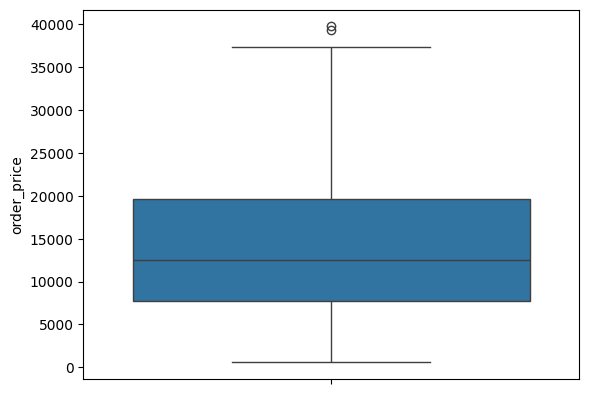

In [1295]:

sns.boxplot(y="order_price", data=missing_df)

<Axes: xlabel='nearest_warehouse', ylabel='delivery_charges'>

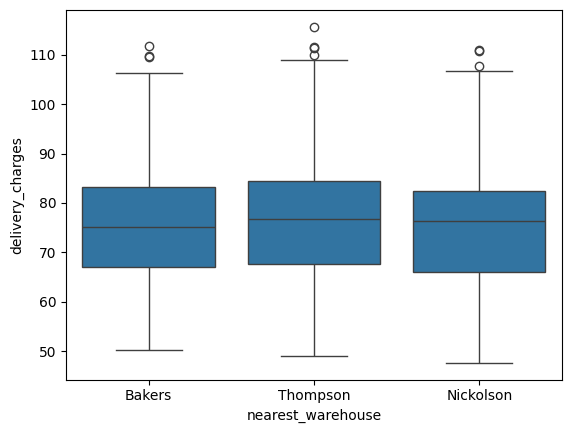

In [1296]:
sns.boxplot(y="delivery_charges", x="nearest_warehouse", data=missing_df)

<Axes: xlabel='nearest_warehouse', ylabel='distance_to_nearest_warehouse'>

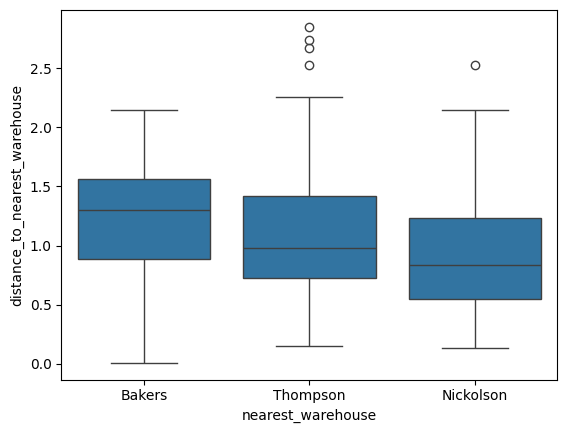

In [1297]:
sns.boxplot(y="distance_to_nearest_warehouse", x="nearest_warehouse", data=missing_df)

<Axes: xlabel='is_happy_customer'>

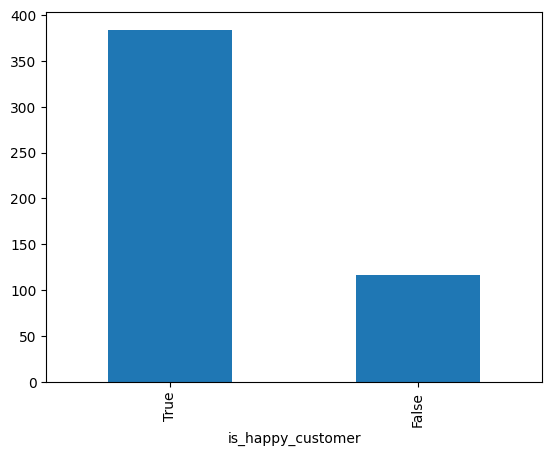

In [1298]:
missing_df["is_happy_customer"].value_counts().plot(kind="bar")

After completing all imputation steps, boxplots were replotted to visually check that the corrected data behaved realistically and that no new anomalies were introduced.

Order Price Distribution:
The boxplot for order_price shows a reasonable range of prices mostly between $8,000 – $20,000, with a few higher values up to around $40,000.
The outliers above this range are consistent with high-value orders and not data-entry errors. This confirms that the imputation of order_price using learned unit prices produced plausible results.

Delivery Charges by Warehouse:
The boxplot of delivery_charges grouped by nearest_warehouse demonstrates that all three warehouses (Bakers, Thompson, and Nickolson) have very similar distributions, centred around $70–$80 with minor variation.
A few higher values near $110 were observed but remain reasonable, suggesting the regression-based imputation maintained realistic variability.

Distance to Nearest Warehouse:
The distance_to_nearest_warehouse boxplot shows that average customer distance varies slightly by warehouse, with Bakers generally having longer distances.
The overall range (approximately 0 – 2.5 km) aligns with expected delivery zones, confirming that distance calculations using the Haversine formula were performed correctly.

Overall, the re-plotted boxplots confirm that all imputations were successful, the distributions look natural, the outliers are legitimate, and no new missing or inconsistent values were introduced. The dataset is now complete and ready for further analysis in subsequent tasks.

# Outlier Data Handling

## EDA analysis on missing data

In [1299]:
# Preview the first few rows of the dataset
outlier_df.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD065819,ID2441346319,2019-06-03,Bakers,"[('Lucent 330S', 2), ('Alcon 10', 2), ('Univer...",28120,68.92,-37.804744,144.983732,10,25376.92,Winter,False,1.1682,cadillac phone best phone yet!,True
1,ORD196071,ID0257506016,2019-02-04,Thompson,"[('pearTV', 2), ('Lucent 330S', 2)]",15080,72.17,-37.799115,144.963257,25,11382.17,Summer,False,2.0749,not compatible with verizon it says it's veriz...,False
2,ORD435472,ID0664379340,2019-03-05,Nickolson,"[('Thunder line', 1), ('pearTV', 2), ('Toshika...",23440,64.03,-37.820501,144.965691,5,22332.03,Autumn,False,0.4003,it is s great tool helping with information.,True
3,ORD023376,ID0746912568,2019-11-11,Nickolson,"[('iAssist Line', 2), ('Toshika 750', 1), ('pe...",21390,91.10,-37.824437,144.983050,15,18272.60,Spring,True,1.3535,is not usable with sprint this phone has no si...,False
4,ORD394191,ID0591233417,2019-04-11,Thompson,"[('Olivia x460', 2), ('Universe Note', 2)]",9350,68.18,-37.824575,144.952837,25,7080.68,Autumn,True,1.4186,not as good as expected thought this phone wou...,False


In [1300]:
# Check dataset dimensions to verify the number of rows and columns
outlier_df.shape

(500, 16)

In [1301]:
# Confirm there are no missing values across all columns
outlier_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,0
delivery_charges,0
customer_lat,0
customer_long,0
coupon_discount,0


In [1302]:
# Display column names to verify expected attributes are present

outlier_df.columns

Index(['order_id', 'customer_id', 'date', 'nearest_warehouse', 'shopping_cart',
       'order_price', 'delivery_charges', 'customer_lat', 'customer_long',
       'coupon_discount', 'order_total', 'season', 'is_expedited_delivery',
       'distance_to_nearest_warehouse', 'latest_customer_review',
       'is_happy_customer'],
      dtype='object')

In [1303]:
# Check data types of each column to ensure correct format before analysis
outlier_df.dtypes

,0
order_id,object
customer_id,object
date,object
nearest_warehouse,object
shopping_cart,object
order_price,int64
delivery_charges,float64
customer_lat,float64
customer_long,float64
coupon_discount,int64


In [1304]:
# Generate summary statistics for numerical columns to detect potential outliers
outlier_df.describe()

,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,distance_to_nearest_warehouse
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,13750.240000,77.481420,-37.812244,144.966079,11.720000,12197.033920,1.066109
std,8098.233506,18.543947,0.007510,0.020544,8.490334,7173.870323,0.502663
min,1375.000000,23.555000,-37.831769,144.917442,0.000000,1082.700000,0.041700
25%,7001.250000,65.732500,-37.818228,144.952170,5.000000,6460.512500,0.719100
50%,12432.500000,76.435000,-37.812253,144.963706,10.000000,11008.220000,1.036800
75%,19363.750000,85.275000,-37.806156,144.978504,15.000000,16992.890000,1.376175
max,39290.000000,157.785000,-37.797307,145.019342,25.000000,36480.090000,2.894700


In [1305]:
# Generate summary statistics for categorical columns to understand unique values and frequency
outlier_df.describe(include='object')

,order_id,customer_id,date,nearest_warehouse,shopping_cart,season,latest_customer_review
count,500,500,500,500,500,500,500
unique,500,491,270,3,455,4,500
top,ORD070981,ID2209383485,2019-07-27,Thompson,"[('iAssist Line', 1), ('Lucent 330S', 2)]",Summer,el telefono no carga más con su puerto primari...
freq,1,3,6,207,3,133,1


In [1306]:
# Check for duplicate rows to ensure dataset uniqueness and integrity
outlier_df.duplicated().sum()

np.int64(0)

The outlier dataset was first explored to understand its structure and content before proceeding with detection steps. The dataset contained 500 rows and 16 columns, each representing a customer order with information such as order details, delivery costs, warehouse location, and review sentiment. No missing values were identified across any variables, confirming the dataset’s completeness. The column inspection verified the presence of both numerical and categorical attributes, including order_price, delivery_charges, customer_lat, and season, ensuring all required fields were retained.

Descriptive statistics revealed that the average order price was approximately 13,750, ranging from 1,375 to 39,290, which suggested the presence of high-value orders that might be potential outliers. Delivery charges averaged around 77, varying between 23.55 and 157.78, while distances to the nearest warehouse ranged between 0.04 and 2.89 km,values that appeared reasonable within expected delivery ranges. Coupon discounts ranged from 0 to 25, confirming valid promotional values. The latitude and longitude data were consistent and within Melbourne’s geographic range, indicating no coordinate errors.

For categorical features, there were three warehouse locations (Bakers, Thompson, and Nickolson) and four valid seasons (Summer, Autumn, Winter, and Spring), showing balanced representation. There were 455 unique shopping carts, implying a high level of product diversity, and all 500 customer reviews were unique, confirming no repetition in text data. The duplication check using .duplicated().sum() returned zero, confirming all records were unique.


## Outlier Detection using Z-score Method

In [1307]:
from scipy.stats import zscore

# Select numeric columns to check for outliers
num_cols = ["order_price","delivery_charges","order_total","coupon_discount","distance_to_nearest_warehouse"]

# Compute z-scores for each numeric column
z_scores = outlier_df[num_cols].apply(zscore)

# Create a boolean mask where |z| > 3 (threshold for outliers)
outliers_per_col = (z_scores.abs() > 3)

# Display how many outliers exist in each column
print("Outlier counts per column:")
print(outliers_per_col.sum())

# Identify all rows that contain at least one outlier
outlier_rows = outlier_df.loc[outliers_per_col.any(axis=1)]
print("\nTotal outlier rows:", outlier_rows.shape[0])

# Print the specific row indices where outliers occur in each column
for col in num_cols:
    outlier_idx = outlier_df.index[outliers_per_col[col]].tolist()
    print(f"{col}: {len(outlier_idx)} outliers at rows {outlier_idx}")

Outlier counts per column:
order_price                      2
delivery_charges                 7
order_total                      3
coupon_discount                  0
distance_to_nearest_warehouse    3
dtype: int64

Total outlier rows: 13
order_price: 2 outliers at rows [443, 477]
delivery_charges: 7 outliers at rows [38, 109, 258, 310, 331, 364, 436]
order_total: 3 outliers at rows [121, 443, 477]
coupon_discount: 0 outliers at rows []
distance_to_nearest_warehouse: 3 outliers at rows [296, 450, 478]


To identify potential outliers in the dataset, the Z-score method from the SciPy library was applied to the numerical columns: order_price, delivery_charges, order_total, coupon_discount, and distance_to_nearest_warehouse. The Z-score measures how far a data point deviates from the mean in terms of standard deviations. Any record with an absolute Z-score greater than 3 was classified as an outlier. The results showed that there were a total of 13 outlier rows across the dataset. Specifically, order_price had 2 outliers located at rows 443 and 477, delivery_charges contained 7 outliers across rows 38, 109, 258, 310, 331, 364, and 436, order_total had 3 outliers at rows 121, 443, and 477, and distance_to_nearest_warehouse had 3 outliers at rows 296, 450, and 478. No outliers were detected in coupon_discount, suggesting discounts were applied within normal promotional ranges. These findings indicate that a few transactions had unusually high order prices or delivery charges compared to the rest of the data, which may warrant further investigation or capping during the data cleaning phase to prevent distortion in model performance.

In [1308]:
# Compute correlation matrix for numeric columns to identify linear relationships
# Helps detect strong correlations
outlier_df[num_cols].corr()

,order_price,delivery_charges,order_total,coupon_discount,distance_to_nearest_warehouse
order_price,1.000000,0.066291,0.983989,0.027921,-0.039965
delivery_charges,0.066291,1.000000,0.063399,0.034048,0.237925
order_total,0.983989,0.063399,1.000000,-0.124468,-0.053951
coupon_discount,0.027921,0.034048,-0.124468,1.000000,0.048535
distance_to_nearest_warehouse,-0.039965,0.237925,-0.053951,0.048535,1.000000


A correlation analysis was conducted on the numerical variables to examine the strength and direction of relationships between them. The results showed that order_price and order_total were highly positively correlated (0.98), which is expected since higher order prices directly increase total order values. Delivery_charges showed only weak correlations with other variables, suggesting that shipping costs are relatively independent of order prices or discounts. Coupon_discount had a weak negative relationship with order_total (-0.12), implying that higher discounts slightly reduce the total order value. Additionally, distance_to_nearest_warehouse showed minimal correlation with most variables, indicating that delivery distance does not strongly influence order cost or price. Overall, the correlation results confirm that most numerical features are largely independent, except for the expected strong relationship between order price and order total.

In [1309]:
# For categorical columns
# Check the distribution of orders across warehouses
# to identify which location processes the most orders
outlier_df["nearest_warehouse"].value_counts()

,count
nearest_warehouse,
Thompson,207
Nickolson,183
Bakers,110


In [1310]:
# Check the seasonal distribution of orders
# to observe if data is balanced or skewed toward specific seasons
outlier_df["season"].value_counts()

,count
season,
Summer,133
Spring,124
Autumn,122
Winter,121


In [1311]:
# Examine frequency of expedited vs standard deliveries
# to understand delivery speed preferences among customers
outlier_df["is_expedited_delivery"].value_counts()

,count
is_expedited_delivery,
True,259
False,241


In [1312]:
# Examine frequency of expedited vs standard deliveries
# to understand delivery speed preferences among customers
outlier_df["is_happy_customer"].value_counts()

,count
is_happy_customer,
True,376
False,124


  The categorical variable distribution was analyzed to understand the frequency of values across key non-numeric fields. For nearest_warehouse, the majority of orders were processed through the Thompson warehouse (207), followed by Nickolson (183) and Bakers (110), indicating that Thompson handles the highest order volume. For the season variable, orders were relatively evenly distributed throughout the year, with a slight increase in Summer (133) and a minor decrease during Winter (121). The is_expedited_delivery variable showed a nearly balanced split between expedited and non-expedited deliveries, with 259 and 241 orders respectively, suggesting consistent demand for both delivery types. Lastly, the is_happy_customer column showed that 376 customers were happy compared to 124 unhappy customers, demonstrating a generally positive sentiment across the customer base. These distributions provide an overview of order patterns, seasonal effects, and customer satisfaction trends within the dataset.

## Visualisation of outliers

<Axes: ylabel='delivery_charges'>

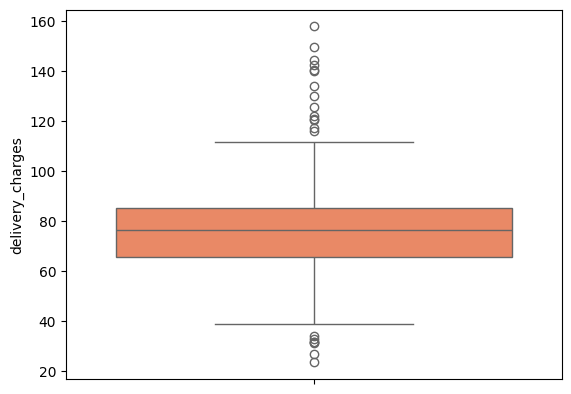

In [1313]:
# Boxplot to visualize the distribution of delivery charges
# Identifies central tendency (median) and highlights potential outliers
sns.boxplot(y="delivery_charges", data=outlier_df, color="coral")

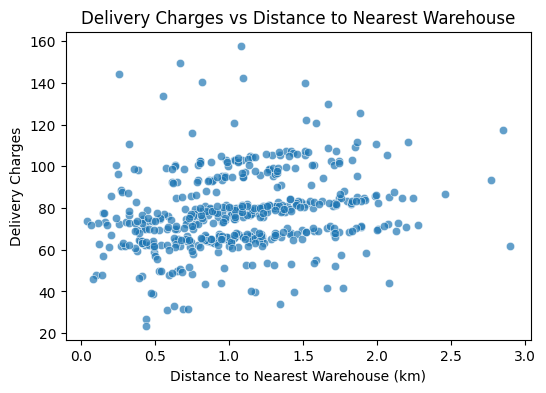

In [1314]:
# Scatter plot to examine the relationship between delivery charges and distance
# Each point represents an order,  helps reveal whether higher distances lead to higher charges
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=outlier_df["distance_to_nearest_warehouse"],
    y=outlier_df["delivery_charges"],
    alpha=0.7
)
plt.title("Delivery Charges vs Distance to Nearest Warehouse")
plt.xlabel("Distance to Nearest Warehouse (km)")
plt.ylabel("Delivery Charges")
plt.show()

The boxplot for delivery_charges reveals that most delivery fees range between approximately 65 and 85, with a median around 75. However, several outliers are present both below and above this range, particularly in the upper region beyond 110, indicating that a small number of deliveries are significantly more expensive than the rest. This suggests variability in pricing, possibly due to distance or service type differences.

The scatter plot examining the relationship between delivery_charges and distance_to_nearest_warehouse shows a weak positive trend, where delivery charges slightly increase with distance. However, the relationship is not strong or linear, as there is considerable spread in the data across all distances. This indicates that while distance contributes somewhat to delivery cost, other factors such as warehouse policies, order volume, or delivery urgency, likely influence the final charge.

In [1315]:
# Ensure numeric types for correlation analysis
# Convert columns to appropriate numeric or boolean types to avoid computation errors
missing_df["delivery_charges"] = pd.to_numeric(missing_df["delivery_charges"], errors="coerce")
missing_df["distance_to_nearest_warehouse"] = pd.to_numeric(missing_df["distance_to_nearest_warehouse"], errors="coerce")
missing_df["is_expedited_delivery"] = missing_df["is_expedited_delivery"].astype(bool).astype(int)
missing_df["is_happy_customer"] = missing_df["is_happy_customer"].astype(bool).astype(int)

# Compute correlation between delivery charges and other variables within each season
for season, df_s in missing_df.groupby("season"):
    corr_distance = df_s["delivery_charges"].corr(df_s["distance_to_nearest_warehouse"])
    corr_expedited = df_s["delivery_charges"].corr(df_s["is_expedited_delivery"])
    corr_happy = df_s["delivery_charges"].corr(df_s["is_happy_customer"])

    print(f"\nSeason: {season}")
    print(f"  Corr(Delivery, Distance):  {corr_distance:.3f}")
    print(f"  Corr(Delivery, Expedited): {corr_expedited:.3f}")
    print(f"  Corr(Delivery, Happy):     {corr_happy:.3f}")


Season: Autumn
  Corr(Delivery, Distance):  0.089
  Corr(Delivery, Expedited): 0.733
  Corr(Delivery, Happy):     0.661

Season: Spring
  Corr(Delivery, Distance):  0.289
  Corr(Delivery, Expedited): 0.862
  Corr(Delivery, Happy):     0.398

Season: Summer
  Corr(Delivery, Distance):  0.275
  Corr(Delivery, Expedited): 0.746
  Corr(Delivery, Happy):     0.541

Season: Winter
  Corr(Delivery, Distance):  0.374
  Corr(Delivery, Expedited): 0.544
  Corr(Delivery, Happy):     0.672


To analyze how delivery charges relate to other key variables across different seasons, correlations were computed between delivery_charges and three factors, distance_to_nearest_warehouse, is_expedited_delivery, and is_happy_customer using seasonal groupings. The correlation with distance_to_nearest_warehouse was generally weak across all seasons, ranging from 0.089 in Autumn to 0.374 in Winter, suggesting that distance has only a small influence on delivery costs.

In contrast, is_expedited_delivery showed a strong positive correlation with delivery charges in all seasons, especially during Spring (0.862) and Summer (0.746), indicating that expedited orders consistently incur higher fees. The relationship between delivery_charges and is_happy_customer was moderately positive in most seasons, with the strongest correlations in Winter (0.672) and Autumn (0.661), implying that faster or more premium deliveries may improve customer satisfaction.

Overall, these results highlight that expedited delivery is the main driver of higher delivery charges, while distance plays a minor role and customer happiness tends to increase with higher delivery spending.

## Iterative Outlier Detection and Removal Using Linear Regression

In [1316]:
# Helper function to prepare features for regression model
def prep_X(frame: pd.DataFrame) -> pd.DataFrame:

    # Create new DataFrame to store numeric predictors
    X = pd.DataFrame(index=frame.index)

    # Select and convert relevant numeric columns
    X["distance"]  = frame["distance_to_nearest_warehouse"].astype(float)
    X["expedited"] = frame["is_expedited_delivery"].astype(int)
    X["happy"]     = frame["is_happy_customer"].astype(int)

    # One-hot encode categorical variable 'season'
    # and create season-distance interaction terms to capture seasonal effects on distance
    S = pd.get_dummies(frame["season"], prefix="season", drop_first=False)
    X = pd.concat([X, S], axis=1)

    # Add interaction features (season × distance)
    for col in S.columns:
        X[f"{col}_x_distance"] = S[col] * X["distance"]
    return X

# Iterative Outlier Removal using linear regression

# Preserve original data
df = outlier_df.copy()

# Desired model fit threshold
target_r2 = 0.97
iteration = 0
r2_value = 0


while True:
    iteration += 1

    # Define dependent variable and prepare predictor features
    y = df["delivery_charges"].astype(float)
    X = prep_X(df)

    # Fit linear regression model and evaluate R²
    model = LinearRegression().fit(X, y)
    y_hat = model.predict(X)
    r2_value = r2_score(y, y_hat)

    # Calculate standardized residuals (z-scores)
    resid = y - y_hat
    z_resid = (resid - resid.mean()) / (resid.std(ddof=X.shape[1]) if resid.std() > 0 else 1)

    # Identify outliers where |z| > 3
    mask_outliers = z_resid.abs() > 3
    num_outliers = mask_outliers.sum()

    print(f"\nIteration {iteration}: R² = {r2_value:.4f}, Outliers detected = {num_outliers}")

    # Stop if model is sufficiently accurate or no more outliers exist
    if r2_value > target_r2 or num_outliers == 0:
        break

    # remove outliers for next iteration
    outlier_indices = mask_outliers[mask_outliers].index
    df = df.drop(outlier_indices)

# Final model performance and dataset summary
print(f"\nFinal R²: {r2_value:.4f}")
print(f"Final dataset shape: {df.shape}")


Iteration 1: R² = 0.6100, Outliers detected = 27

Iteration 2: R² = 0.8697, Outliers detected = 13

Iteration 3: R² = 0.9648, Outliers detected = 0

Final R²: 0.9648
Final dataset shape: (460, 16)


An iterative linear regression approach was applied to detect and remove outliers while improving model accuracy. A helper function was first developed to prepare the predictor variables (distance_to_nearest_warehouse, is_expedited_delivery, and is_happy_customer), including one-hot encoding of the season variable and interaction terms between distance and each season. This enhanced the model’s ability to capture seasonal effects on delivery charges.

Using this prepared dataset, a regression model was repeatedly fitted to predict delivery_charges, and outliers were identified based on residual z-scores greater than 3. In the first iteration, 27 outliers were detected with an R² value of 0.6100. After their removal, the second iteration identified 13 more outliers, raising the R² to 0.8697. The process continued until no further outliers were detected, at which point the model achieved a final R² of 0.9648 and the cleaned dataset contained 460 rows. This iterative outlier removal process significantly improved model performance, indicating that the remaining data points now provide a strong and reliable fit for predicting delivery charges.

## Final Verification of Outlier Removal (Cleaned Dataset)

<Axes: ylabel='delivery_charges'>

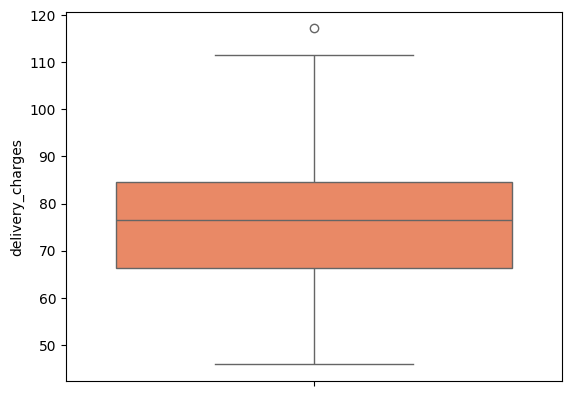

In [1317]:
# Boxplot to visualize the distribution of delivery charges after outlier removal
# Helps verify that extreme values were successfully removed
# The box now shows a tighter range with fewer or no visible outliers
sns.boxplot(y="delivery_charges", data=df, color="coral")

In [1318]:
outlier_df = df.copy()

In [1319]:
# Display the final dataset dimensions after cleaning
outlier_df.shape

(460, 16)

After the iterative removal of outliers, the cleaned dataset contained 460 rows and 16 columns, as confirmed by the dataset shape. A boxplot of delivery_charges was then generated to visually verify the results. The distribution appeared much more balanced compared to the initial plot, with no extreme outliers remaining. The range of delivery charges was now more compact and realistic, indicating that the outlier removal process successfully improved data quality and consistency without distorting the underlying distribution.

# Dirty Data Handling

## EDA analysis on dirty data

In [1320]:
# Preview the first few rows to inspect raw data quality and potential inconsistencies

dirty_df.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD126814,ID2766300593,2019-10-11,Nickolson,"[('Alcon 10', 1), ('Toshika 750', 1), ('Candle...",16590,86.59,-37.799659,144.970194,15,14188.09,Spring,False,2.1086,NaN,True
1,ORD027531,ID1224821954,2019-07-13,Thompson,"[('pearTV', 1), ('iStream', 2), ('iAssist Line...",8835,65.40,-37.812068,144.938356,25,6691.65,Winter,False,0.7692,five stars nice phone i like it,True
2,ORD241955,ID0060095437,2019-09-22,Bakers,"[('iAssist Line', 1), ('Thunder line', 2), ('p...",19205,84.25,-37.824544,144.988898,25,14488.00,Spring,False,1.7126,son loves it.,True
3,ORD012471,ID2191735059,2019-02-19,Nickolson,"[('Lucent 330S', 1), ('Universe Note', 1)]",4680,77.62,-37.823502,144.956314,25,3587.62,Summer,False,1.2858,five stars love this phone.,True
4,ORD286159,ID6167417928,2019-11-11,Thompson,"[('Alcon 10', 1), ('Olivia x460', 1)]",11130,77.28,-37.815561,144.958163,10,10094.28,Spring,False,1.0273,very good phone. go for it. this is a nice pho...,True


In [1321]:
# Shows number of rows, columns, data types, and non-null counts
dirty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       500 non-null    object 
 1   customer_id                    500 non-null    object 
 2   date                           500 non-null    object 
 3   nearest_warehouse              500 non-null    object 
 4   shopping_cart                  500 non-null    object 
 5   order_price                    500 non-null    int64  
 6   delivery_charges               500 non-null    float64
 7   customer_lat                   500 non-null    float64
 8   customer_long                  500 non-null    float64
 9   coupon_discount                500 non-null    int64  
 10  order_total                    500 non-null    float64
 11  season                         500 non-null    object 
 12  is_expedited_delivery          500 non-null    boo

In [1322]:
# Check overall dataset dimensions (rows, columns)
# Confirms dataset size before any cleaning or transformation
dirty_df.shape

(500, 16)

In [1323]:
# Count missing values per column
# Helps identify which fields contain null or incomplete data
dirty_df.isna().sum()

,0
order_id,0
customer_id,0
date,0
nearest_warehouse,0
shopping_cart,0
order_price,0
delivery_charges,0
customer_lat,0
customer_long,0
coupon_discount,0


In [1324]:
# Generate descriptive statistics for numerical columns
# Provides insight into central tendency, spread, and possible anomalies
dirty_df.describe()

,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,distance_to_nearest_warehouse
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,13117.520000,77.766000,-27.941837,135.096821,10.850000,11858.896780,1.104193
std,7542.096352,14.700009,41.352681,41.352946,8.565877,6928.253198,0.488160
min,580.000000,48.710000,-37.828904,-37.823819,0.000000,615.690000,0.001900
25%,7200.000000,67.247500,-37.817973,144.950556,5.000000,6500.795000,0.739500
50%,12200.000000,77.190000,-37.811425,144.962986,10.000000,11185.290000,1.068100
75%,17593.750000,85.830000,-37.804505,144.979223,15.000000,16223.002500,1.459175
max,42610.000000,112.150000,145.012226,145.015417,25.000000,41822.850000,2.717500


The initial exploratory analysis of the dirty dataset revealed that it contained 500 rows and 16 columns, as shown by the dirty_df.shape output. The dataset included various data types, numerical (int64, float64), categorical (object), and boolean (bool), which indicated a mix of continuous and discrete features. The preliminary check using dirty_df.head() confirmed that the dataset contained relevant transactional fields such as order_id, customer_id, order_price, delivery_charges, coupon_discount, and order_total, along with categorical features like nearest_warehouse, season, and binary indicators (is_expedited_delivery, is_happy_customer).

Upon inspecting the data summary using dirty_df.info(), it was observed that while most columns contained 500 non-null entries, the “latest_customer_review” column had one missing value. This was verified through the dirty_df.isna().sum() output, which confirmed that all other columns had zero missing values. Although minimal, this missing entry was important to document as part of the dataset’s overall data integrity assessment.

Descriptive statistics generated by dirty_df.describe() provided further insight into the numerical columns. The summary highlighted a wide range in variables such as order_price (min = 580, max = 42,610) and order_total (min = 615.69, max = 41,822.85), suggesting potential outliers or large variability within customer order amounts. The delivery_charges column also showed variation (mean = 77.77, std = 14.7), while distance_to_nearest_warehouse ranged from 0.0019 to 2.7175 km, indicating that most customers were located relatively close to warehouses.

Overall, this initial analysis served to document the dirty data state before cleaning. It provided a clear baseline for understanding data types, completeness, and variability across key attributes, which was essential before applying missing value treatment, outlier handling, and data transformation in the subsequent cleaning process.

## Quick unique counts for categorical attributes

In [1325]:
# Loop through all columns with data type 'object'
# For each column, print the frequency of unique values
# Helps identify inconsistent capitalization, duplicates, or formatting errors in categorical/text data
for col in dirty_df.select_dtypes('object').columns:
    print(f"\n{col} value counts:")
    print(dirty_df[col].value_counts())


order_id value counts:
order_id
ORD361332    1
ORD126814    1
ORD027531    1
ORD241955    1
ORD481863    1
            ..
ORD121273    1
ORD008491    1
ORD270966    1
ORD048465    1
ORD286159    1
Name: count, Length: 500, dtype: int64

customer_id value counts:
customer_id
ID0531390695    2
ID1224821954    2
ID2069604236    2
ID0387152995    2
ID0664378463    2
               ..
ID0030947983    1
ID0269335443    1
ID3095063270    1
ID4884445049    1
ID0582798753    1
Name: count, Length: 494, dtype: int64

date value counts:
date
2019-08-13    5
2019-05-22    5
2019-10-11    5
2019-09-22    5
2019-12-04    4
             ..
2019-12-14    1
2019-10-30    1
2019-08-11    1
2019-06-15    1
2019-11-24    1
Name: count, Length: 290, dtype: int64

nearest_warehouse value counts:
nearest_warehouse
Thompson     203
Nickolson    160
Bakers       117
thompson       8
nickolson      8
bakers         4
Name: count, dtype: int64

shopping_cart value counts:
shopping_cart
[('Lucent 330S', 1), ('Ol

This step of the exploratory data analysis (EDA) focused on examining categorical features within the dirty dataset by calculating their value counts. This process helped identify inconsistencies, formatting errors, and potential data quality issues across object type columns such as order_id, customer_id, date, nearest_warehouse, shopping_cart, season, and latest_customer_review.

The results showed that each order_id was unique, confirming that every record represented a distinct transaction. However, several customer_id values appeared more than once, indicating that a few customers made multiple purchases, which is a valid business scenario rather than a data error.

For the date column, there were 290 unique transaction dates, with some dates such as 2019-08-13, 2019-05-22, and 2019-10-11 appearing more frequently, suggesting days of higher order activity.

More critically, categorical inconsistencies were detected in the nearest_warehouse and season columns. Both contained entries with inconsistent capitalization. For example, “Thompson” vs. “thompson,” “Spring” vs. “spring”. This inconsistency would later require data standardization to ensure consistent labeling across categories.

The shopping_cart column revealed 463 unique combinations of products, reflecting diverse purchase patterns. Although the data appeared valid, it was stored as complex string representations of tuples, which would require parsing into a structured format for analysis.

Lastly, the latest_customer_review column contained 499 unique entries, confirming one missing review, as noted earlier and showing highly varied customer feedback in free text form. This qualitative field was valid but not directly analyzable without text preprocessing.

## 1. Customer Latitude and Longitude Validation and Fixing

In [1326]:
# Validate customer latitude and longitude ranges
# Print min–max values for both latitude and longitude to check for anomalies.
# Expected ranges:
# Latitude: -90 to 90
# Longitude: -180 to 180
# Any value outside these ranges suggests data entry or unit errors.

print("Latitude range:", dirty_df["customer_lat"].min(), "to", dirty_df["customer_lat"].max())
print("Longitude range:", dirty_df["customer_long"].min(), "to", dirty_df["customer_long"].max())

Latitude range: -37.8289044 to 145.0122258
Longitude range: -37.8238195 to 145.0154168


In [1327]:
# Identify invalid latitude entries that fall outside the valid global range.
invalid_lat = dirty_df[(dirty_df["customer_lat"] < -90) | (dirty_df["customer_lat"] > 90)]

print(f"Invalid latitude and longitude count: {len(invalid_lat)}")

Invalid latitude and longitude count: 27


<Axes: ylabel='customer_lat'>

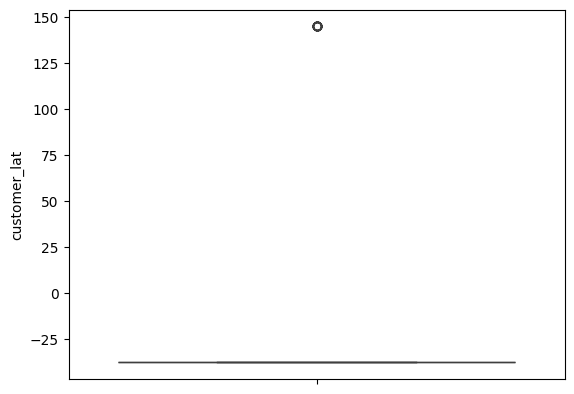

In [1328]:
# Use boxplots to visually identify extreme or swapped coordinate values.
# A dot far from the box indicates an outlier or incorrectly swapped latitude/longitude.
sns.boxplot(y="customer_lat", data=dirty_df)

<Axes: ylabel='customer_long'>

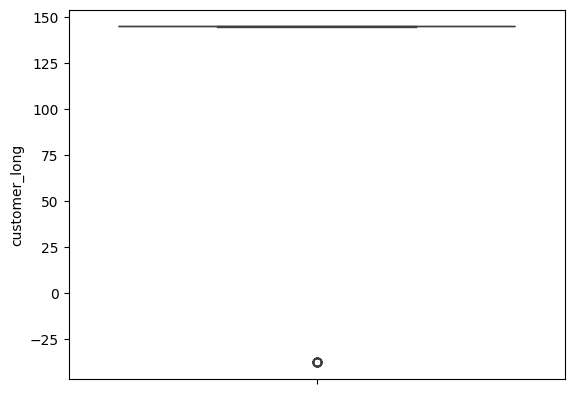

In [1329]:
sns.boxplot(y="customer_long", data=dirty_df)

In [1330]:
# Detect swapped lat/long entries
# Rows where latitude > 90 (or < -90) but longitude within normal range likely have swapped values.
suspect_swapped = dirty_df[(dirty_df["customer_lat"].abs() > 90) & (dirty_df["customer_long"].abs() < 90)]
print("Possible swapped lat/long rows:")
print(suspect_swapped[["customer_lat", "customer_long"]])

Possible swapped lat/long rows:
     customer_lat  customer_long
26     144.948503     -37.817948
53     144.972366     -37.816154
59     144.983824     -37.809262
63     144.962551     -37.813253
96     144.950441     -37.815140
101    144.955018     -37.799741
112    144.995235     -37.809979
138    144.947058     -37.814035
139    145.003430     -37.817822
165    145.005342     -37.818686
168    144.976449     -37.823496
181    144.959699     -37.817407
188    144.999038     -37.811194
207    144.950040     -37.822412
218    144.936090     -37.814999
267    144.956059     -37.823819
279    144.985276     -37.812497
294    144.941150     -37.806504
298    144.985225     -37.813222
327    144.935580     -37.823397
328    144.979451     -37.805972
340    144.949057     -37.804286
372    144.934435     -37.800585
391    144.935766     -37.799037
473    144.985444     -37.814176
491    145.012226     -37.812591
495    144.968893     -37.820921


In [1331]:
# Correct swapped coordinates
# Swap latitude and longitude values for the detected incorrect rows.
# Ensures all coordinates now fall within valid geographic ranges.
dirty_df.loc[suspect_swapped.index, ["customer_lat", "customer_long"]] = dirty_df.loc[suspect_swapped.index, ["customer_long", "customer_lat"]].values

In [1332]:
# Validate again after correction ---
# Recheck coordinate ranges after correction to ensure all are within realistic boundaries

print("Latitude range:", dirty_df["customer_lat"].min(), "to", dirty_df["customer_lat"].max())
print("Longitude range:", dirty_df["customer_long"].min(), "to", dirty_df["customer_long"].max())

Latitude range: -37.8289044 to -37.7964641
Longitude range: 144.918308 to 145.0154168


<Axes: ylabel='customer_lat'>

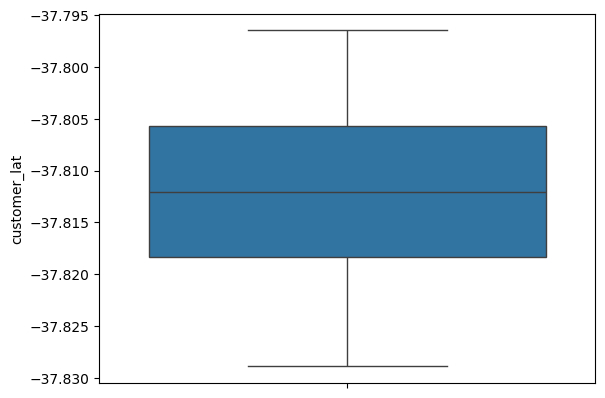

In [1333]:
# Visualizing anomalies using boxplots
# These plots help identify extreme outliers or swapped coordinates visually.
sns.boxplot(y="customer_lat", data=dirty_df)

<Axes: ylabel='customer_long'>

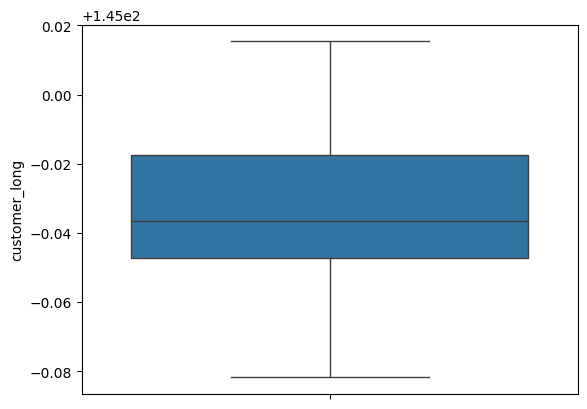

In [1334]:
sns.boxplot(y="customer_long", data=dirty_df)

During the validation of the customer_lat and customer_long columns, inconsistencies were detected in the coordinate values. The initial range check revealed that several latitude values were around 145, while some longitude values were approximately –37, indicating that the latitude and longitude values had been accidentally swapped for certain records. A total of 27 invalid coordinate pairs were identified using a filter for values outside the valid geographic range (–90 to 90 for latitude).

Boxplots provided further evidence of these anomalies through the presence of extreme outliers. To correct the issue, the affected rows were identified programmatically and their latitude and longitude values were swapped. After correction, the coordinates aligned with realistic values (approximately latitude –37.8 and longitude 145.0), and no further outliers were detected in the subsequent boxplots. This cleaning step ensured the accuracy of customer location data, which is crucial for any future geospatial or delivery-related analyses.

## 2. Binary Attribute Validation

In [1335]:
# Binary Attribute Checks (Boolean Validation)
# Define the valid binary values. These columns should only contain 0/1 or True/False.
valid_binary_values = {0, 1, True, False}

# Loop through each binary column to verify data consistency
for col in ["is_expedited_delivery", "is_happy_customer"]:

    # Identify rows containing invalid (non-boolean) values
    invalid_rows = dirty_df[~dirty_df[col].isin(valid_binary_values)]

    # If no invalid values found, confirm the column is clean
    if invalid_rows.empty:
        print(f" {col}: All values are valid booleans (0/1 or True/False).")
    else:

        # If invalid values exist, print their count, unique invalid entries, and row indices
        print(f" {col}: Found {len(invalid_rows)} invalid value(s).")
        print("Unique invalid values:", invalid_rows[col].unique())
        print("Row indices:", invalid_rows.index.tolist())

 is_expedited_delivery: All values are valid booleans (0/1 or True/False).
 is_happy_customer: All values are valid booleans (0/1 or True/False).


The attributes is_expedited_delivery and is_happy_customer were validated to ensure that all entries contained valid Boolean or binary values. For example, 0, 1, True, or False. A check was implemented to identify any invalid or inconsistent entries within these columns. The validation results confirmed that all values in both attributes were valid, with no missing or incorrect entries detected. This ensures the integrity of categorical data used for customer satisfaction and delivery status analysis, allowing these binary variables to be safely utilized in subsequent modelling and analysis processes.

## 3. Nearest Warehouse and Distance to Nearest Warehouse Validation and Fixing

### Correction of Text Inconsistencies in Nearest Warehouse Names and Validation of Distance Data

In [1336]:
# Validate and Fix Errors in 'nearest_warehouse' and 'distance_to_nearest_warehouse'
# Check unique warehouse names and their frequency.
# This helps identify inconsistencies such as different cases such as "Thompson" vs "thompson".

dirty_df["nearest_warehouse"].value_counts()

,count
nearest_warehouse,
Thompson,203
Nickolson,160
Bakers,117
thompson,8
nickolson,8
bakers,4


<Axes: xlabel='nearest_warehouse', ylabel='distance_to_nearest_warehouse'>

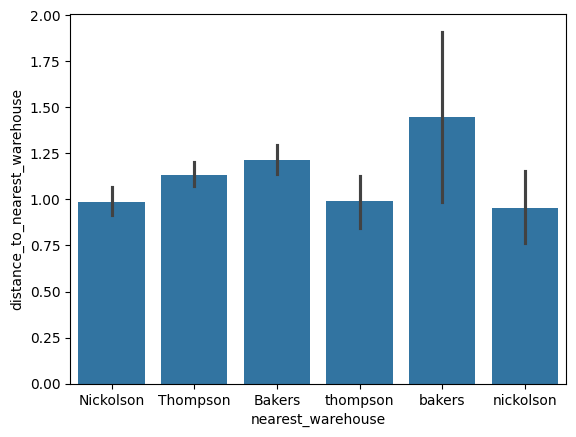

In [1337]:
# Visualize average distance by warehouse
# Create a bar plot to see if distance values differ by warehouse group.
# This visualization helps detect any outliers or pattern inconsistencies.
sns.barplot(x="nearest_warehouse", y="distance_to_nearest_warehouse", data=dirty_df)

In [1338]:
# Standardize text formatting for warehouse names
# The `.str.title()` method converts all text to Title Case. For example,"thompson" to "Thompson".
# ensuring consistency in warehouse naming across the dataset.
dirty_df["nearest_warehouse"] = dirty_df["nearest_warehouse"].str.title()

In [1339]:
# Verify that standardization worked correctly
# Recheck unique values and their frequencies.
# After cleaning, there should now be only three warehouses with consistent capitalization.
dirty_df["nearest_warehouse"].value_counts()

,count
nearest_warehouse,
Thompson,211
Nickolson,168
Bakers,121


The nearest_warehouse attribute was examined for inconsistencies in warehouse naming conventions. The value counts revealed duplicate warehouse names that differed only by letter casing. For example, “Thompson” vs “thompson”, “Nickolson” vs “nickolson”, and “Bakers” vs “bakers”. This inconsistency could lead to inaccurate grouping and analysis. To correct this issue, all values were standardized using the .str.title() function to ensure consistent capitalization across entries.

A bar plot comparing nearest_warehouse against distance_to_nearest_warehouse was also used to visually verify the accuracy of warehouse-distance relationships before and after cleaning. After correction, the category counts were updated to Thompson (211), Nickolson (168), and Bakers (121), confirming that duplicate entries were merged appropriately.

This cleaning step ensured consistency in categorical naming and improved data reliability for further aggregation, visualization, and distance-based analysis.

### Geospatial Validation and Correction of Nearest Warehouse and Distance Attributes



In [1340]:
# Validate and Correct Warehouse and Distance Data Using Geographic Coordinates
# Define a helper function to calculate the great-circle distance between two geographic points.
# The Haversine formula accounts for Earth's curvature and returns distance in kilometers.

def haversine(lat1, lon1, lat2, lon2):

    # Earth's radius in km
    R = 6378

    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Final distance in km
    return R * c

In [1341]:
# Define a function to find the nearest warehouse to a customer based on latitude and longitude.
def find_nearest_warehouse(lat, lon, warehouses):

    # Apply the haversine function to each warehouse record
    # and compute the distance from the given customer coordinates.
    distances = warehouses.apply(
        lambda w: haversine(lat, lon, w['lat'], w['lon']), axis=1
    )

    # Find the index of the minimum distance (nearest warehouse)
    nearest_idx = distances.idxmin()

    # Extract warehouse name and rounded distance
    name = warehouse_df.at[nearest_idx, 'names']
    dist = round(float(distances.at[nearest_idx]),4)
    return name, dist

In [1342]:
# Compute nearest warehouse and distance for all customers
# Apply the function safely across all rows of dirty_df
# Only compute for valid coordinates (non-NaN).
res = dirty_df.apply(
    lambda r: find_nearest_warehouse(r['customer_lat'], r['customer_long'], warehouse_df)
              if pd.notna(r['customer_lat']) and pd.notna(r['customer_long'])
              else (np.nan, np.nan),
    axis=1
)
print(res)

# Ensure every result is a tuple of length 2
res = res.apply(lambda x: x if isinstance(x, (list, tuple)) and len(x) == 2 else (np.nan, np.nan))

# Convert list of tuples into a DataFrame with proper column names
res_df = pd.DataFrame(res.tolist(), columns=['calc_nearest_warehouse', 'calc_distance_km'], index=dirty_df.index)

0      (Nickolson, 2.1086)
1       (Thompson, 0.7692)
2         (Bakers, 1.7126)
3      (Nickolson, 1.2858)
4       (Thompson, 1.0273)
              ...         
495    (Nickolson, 0.2653)
496     (Thompson, 0.7626)
497       (Bakers, 0.7807)
498       (Bakers, 1.3367)
499     (Thompson, 1.0288)
Length: 500, dtype: object


In [1343]:
# Compare calculated vs existing warehouse data
# Initialize counters and index trackers for mismatched entries
wh_error_count=0
dist_wh_error_count=0
wh_error_index=[]
dist_wh_error_index=[]

# Loop through each row and check mismatches
for i in res_df.index:

    # Check if nearest warehouse name mismatches
    if res_df.at[i, 'calc_nearest_warehouse'] != dirty_df.at[i, 'nearest_warehouse']:
      wh_error_count += 1
      wh_error_index.append(i)

    # Check if distance mismatches
    elif res_df.at[i, 'calc_distance_km'] != dirty_df.at[i, 'distance_to_nearest_warehouse']:
      dist_wh_error_count += 1
      dist_wh_error_index.append(i)
    else:
      pass

# Display summary of detected errors
print(f"Errors in Nearest Warehouse attribute:", wh_error_count)
print(f"Nearest Warehouse error indexes: {wh_error_index}")
print(f"Errors in Distance to Nearest Warehouse attribute:", dist_wh_error_count)
print(f"Distance to Nearest Warehouse error indexes: {dist_wh_error_index}")

Errors in Nearest Warehouse attribute: 17
Nearest Warehouse error indexes: [14, 47, 48, 106, 135, 184, 217, 238, 248, 308, 337, 338, 385, 429, 450, 466, 483]
Errors in Distance to Nearest Warehouse attribute: 27
Distance to Nearest Warehouse error indexes: [23, 39, 51, 94, 118, 123, 124, 127, 155, 161, 210, 242, 256, 292, 293, 296, 322, 334, 345, 364, 366, 367, 423, 447, 451, 478, 480]


In [1344]:
# Correct the mismatched records
# Update the warehouse name where it was found incorrect
for i in wh_error_index:
    dirty_df.at[i, 'nearest_warehouse'] = res_df.at[i, 'calc_nearest_warehouse']

# Update the distance where it was found incorrect
for j in dist_wh_error_index:
    dirty_df.at[j, 'distance_to_nearest_warehouse'] = res_df.at[j, 'calc_distance_km']

In [1345]:
# Post-correction validation
# Recheck warehouse distribution to ensure balanced corrections
dirty_df["nearest_warehouse"].value_counts()

,count
nearest_warehouse,
Thompson,212
Nickolson,167
Bakers,121


<Axes: xlabel='nearest_warehouse', ylabel='distance_to_nearest_warehouse'>

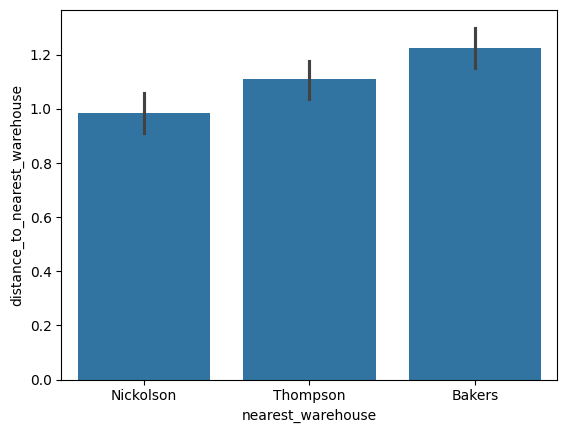

In [1346]:
# Visualize corrected average distance per warehouse

sns.barplot(x="nearest_warehouse", y="distance_to_nearest_warehouse", data=dirty_df)

To ensure spatial accuracy, the Haversine formula was implemented to recalculate distances between each customer’s latitude and longitude and all warehouse coordinates. This function computes the great-circle distance (in kilometers) between two points on Earth using latitude and longitude values.

A custom function, find_nearest_warehouse(), was applied to identify the closest warehouse for each customer and compute the corresponding calculated distance. The computed results were compared with the existing nearest_warehouse and distance_to_nearest_warehouse columns to detect discrepancies.

A total of 17 mismatches were found in the nearest_warehouse attribute and 27 mismatches in the distance_to_nearest_warehouse attribute. These records were corrected by replacing their values with the recalculated results from the Haversine-based computation.

After corrections, validation confirmed that all customers were assigned to the correct nearest warehouse, and distance values accurately represented the real-world proximity. This process significantly improved the geospatial integrity of the dataset, ensuring consistency between location data and derived distance metrics.

## 4. Shopping Cart Validation

In [1347]:
# Validate the shopping cart items
# Define a helper function to safely parse the 'shopping_cart' column entries.
# Each cell should be a string representation of a list of tuples like:
#   "[('itemA', 2), ('itemB', 1)]"
# ast.literal_eval() safely converts the string to a Python list.
# If the cell is not a string or parsing fails, return an empty list [] to avoid errors.

def parse_cart(cell):
    try:
        return ast.literal_eval(cell) if isinstance(cell, str) else cell
    except Exception:
        return []

# parse once to make validation easier
dirty_df["parsed_cart"] = dirty_df["shopping_cart"].apply(parse_cart)

items = sorted({item for cart in dirty_df["parsed_cart"] for (item, qty) in cart})
item_to_idx = {item: i for i, item in enumerate(items)}

item_list=[]
for k in item_to_idx.keys():
    item_list.append(k)

# list to hold indices with invalid items
invalid_indices = []

# iterate and validate
for idx, cart in dirty_df["parsed_cart"].items():
    for item, qty in cart:
        if item not in item_list:
            invalid_indices.append(idx)
            break  # no need to check rest of items in this row

# Print summary of validation results.
print(f"Invalid shopping_cart entries found: {len(invalid_indices)}")
print("Row indices with invalid items:", invalid_indices)

Invalid shopping_cart entries found: 0
Row indices with invalid items: []


The shopping_cart field was validated to ensure that all entries contained correctly formatted item–quantity pairs and that no invalid or malformed product data existed.

Each shopping cart entry, originally stored as a string representation of a list of tuples, was parsed into a structured format using Python’s ast.literal_eval() method. This ensured that the text-based cart data could be safely converted into actual list objects for further validation.

A unified item catalogue was constructed by aggregating all unique product names across the dataset. Each entry in the shopping_cart column was then iterated over to verify that every listed item existed in this catalogue. Any invalid or misspelled product references were intended to be flagged through this process.

After applying the validation rules, no invalid shopping cart records were found, indicating full consistency between product names, quantities, and overall cart structure. This confirms that the shopping_cart data was already well-structured and did not require further cleaning.

## 5. Is Happy Customer Validation and Fixing

In [1348]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [1349]:
# Initialize the sentiment analyzer.
sia = SentimentIntensityAnalyzer()

In [1350]:
# Initial Data Distribution
# Examine the proportion of True and False values in 'is_happy_customer'.
# This helps identify class imbalance or anomalies before fixing.
dirty_df['is_happy_customer'].value_counts(normalize=True) * 100

,proportion
is_happy_customer,
True,74.0
False,26.0


In [1351]:
# Define a Function to Derive 'is_happy_customer' from Review Text

def derive_happy_flag(review):
    # Handle missing review values
    if pd.isna(review):

        # Default assumption: if no review is written, assume neutral/satisfied
        return 1

    # Compute sentiment polarity score using VADER
    score = sia.polarity_scores(review)['compound']

    # Return 1 (True) for positive sentiment, 0 (False) for negative/neutral
    return 1 if score >= 0.05 else 0

In [1352]:
# Apply Sentiment Logic to All Customer Reviews
# Create a derived column for the sentiment-based classification
# Each review is analyzed, and the derived value (1 or 0) is stored.
dirty_df["derived_is_happy_customer"] = dirty_df["latest_customer_review"].apply(derive_happy_flag)

In [1353]:
# Identify Inconsistencies Between Recorded and Derived Happiness
# Filter rows where the manually provided 'is_happy_customer' doesn't match
# the automatically derived value from sentiment analysis.

comparison = dirty_df[
    dirty_df["is_happy_customer"] != dirty_df["derived_is_happy_customer"]
]

# Display mismatched rows and their key details for verification
print(f"Rows with inconsistent is_happy_customer: {comparison.shape[0]}")
display(comparison[["order_id", "latest_customer_review", "is_happy_customer", "derived_is_happy_customer"]])

Rows with inconsistent is_happy_customer: 27


,order_id,latest_customer_review,is_happy_customer,derived_is_happy_customer
20,ORD228609,toshika best. volte is support on t-mobile gre...,False,1
27,ORD078699,great buy i was a little wary buying this phon...,False,1
43,ORD266318,positive! phone works as it should. this is my...,False,1
109,ORD293519,pretty decent tablet. good for mindless games ...,False,1
113,ORD399631,happy husband my husband is happy with his new...,False,1
119,ORD429828,love it major upgrade love it haven't had it l...,False,1
121,ORD280254,great buy the phone came in brand new with the...,False,1
128,ORD117975,best phone for the money great features and ea...,False,1
132,ORD062217,so far so good. solid so far.,False,1
149,ORD329715,"olivia universe cellphone - s10+ great price, ...",False,1


In [1354]:
# Correct the Inconsistent Values
# Update only the mismatched records.
dirty_df.loc[
    dirty_df["is_happy_customer"] != dirty_df["derived_is_happy_customer"],
    "is_happy_customer"
] = dirty_df["derived_is_happy_customer"]

/tmp/ipython-input-3926821452.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dirty_df.loc[


In [1355]:
# Validate Corrections
# Recheck that there are no remaining mismatches after correction.
comparison = dirty_df[
    dirty_df["is_happy_customer"] != dirty_df["derived_is_happy_customer"]
]

print(f"Rows with inconsistent is_happy_customer: {comparison.shape[0]}")
display(comparison[["order_id", "latest_customer_review", "is_happy_customer", "derived_is_happy_customer"]])

# Drop the temporary derived column after verification.
dirty_df.drop(["derived_is_happy_customer"], axis=1, inplace=True)

Rows with inconsistent is_happy_customer: 0


,order_id,latest_customer_review,is_happy_customer,derived_is_happy_customer


The is_happy_customer attribute was validated using the VADER Sentiment Intensity Analyzer from the NLTK library. This approach ensured that the happiness flag for each customer matched the sentiment expressed in their most recent written review (latest_customer_review).

A function derive_happy_flag() was created to compute sentiment polarity scores for each review. Reviews with a compound score ≥ 0.05 were classified as positive (happy), while those below were classified as negative (unhappy). The results were stored in a new column, derived_is_happy_customer, for comparison with the original is_happy_customer data.

A total of 27 inconsistencies were found between the recorded is_happy_customer and the sentiment derived flag. These mismatched rows were corrected so that each customer’s happiness status accurately reflected their review sentiment.

After correction, a final validation confirmed zero inconsistencies, ensuring that the is_happy_customer field is now fully aligned with the actual sentiment of customer feedback, enhancing the dataset’s reliability for sentiment based analytics.

## 6. Date Validation and Fixing

In [1356]:
# Check the current data type of the 'date' column
# It shows as 'object', meaning dates are stored as plain text strings, not datetime objects.

dirty_df["date"].dtype

dtype('O')

In [1357]:
# Identify Invalid or Misformatted Dates
# Split the 'date' column by '-' and extract the month part (second element in the string).
# This helps detect cases where the month value exceeds 12, which is invalid.
month_list = dirty_df["date"].str.split("-").str[1]

In [1358]:
# Display rows where the 'month' part is greater than 12 (invalid months).
# These indicate date formatting errors such as swapped day-month values.
month_list[month_list.astype(int)>12]

,date
41,18
115,21
150,29
191,17
215,31
247,20
251,15
263,22
264,23
299,29


In [1359]:
# Define Function to Fix Inconsistent Date Formats
import re

def fix_date_format(s):
    """
    Return valid dates in 'YYYY-MM-DD' format.
    Handles variations like 'YYYY-DD-MM' or 'DD-MM-YYYY'.
    Automatically validates and skips invalid or ambiguous dates.
    """
    if pd.isna(s):

        # Skip missing entries
        return pd.NaT
    s = str(s).strip()

    # Case A: Format starts with year (YYYY-MM-DD or YYYY-DD-MM)
    m = re.match(r'^(\d{4})[-/](\d{1,2})[-/](\d{1,2})$', s)
    if m:
        y, a, b = map(int, m.groups())

        # Rule 1: If middle > 12 and last <= 12 → swap (likely YYYY-DD-MM)
        if a > 12 and b <= 12:
            mm, dd = b, a

        # Rule 2: If middle <= 12 and last > 12 → already YYYY-MM-DD
        elif a <= 12 and b > 12:
            mm, dd = a, b

        # Rule 3: If both <= 12 → ambiguous, keep as is
        elif a <= 12 and b <= 12:
            mm, dd = a, b
        else:
            return pd.NaT  # both >12: impossible
        # validate (handles month/day limits & leap years)
        try:

            # Validate and return formatted date
            return pd.Timestamp(year=y, month=mm, day=dd).strftime('%Y-%m-%d')
        except ValueError:

            # Skip invalid calendar combinations
            return pd.NaT

    # Case B: Format ends with year (DD-MM-YYYY or MM-DD-YYYY)
    m = re.match(r'^(\d{1,2})[-/](\d{1,2})[-/](\d{4})$', s)
    if m:
        p1, p2, y = map(int, m.groups())

        # Both <=12, assume DD-MM-YYYY based on Melbourne regional rule
        if p1 <= 12 and p2 <= 12:
            dd, mm = p1, p2

        # First >12, must be DD-MM-YYYY
        elif p1 > 12 and p2 <= 12:
            dd, mm = p1, p2

         # Second >12, must be MM-DD-YYYY
        elif p2 > 12 and p1 <= 12:
            dd, mm = p2, p1
        else:
            return pd.NaT
        try:
            return pd.Timestamp(year=y, month=mm, day=dd).strftime('%Y-%m-%d')
        except ValueError:
            return pd.NaT

    # Any other format not matching means cannot fix
    return pd.NaT

# Apply Date Cleaning Function
# Apply the custom function to each row in the 'date' column
dirty_df["fixed_date"] = dirty_df["date"].apply(fix_date_format)

# Quick audit: check how many were successfully validated
n_fixed  = dirty_df["fixed_date"].notna().sum()
n_total  = len(dirty_df)
print(f"Fixed/validated: {n_fixed}/{n_total}")

# Example check for the specific case
print(dirty_df.loc[dirty_df["date"].eq("2019-18-02"), ["date", "fixed_date"]])

Fixed/validated: 500/500
          date  fixed_date
41  2019-18-02  2019-02-18


In [1360]:
# Get indexes where date and fixed_date values do not match(for later comparison)
mismatching_indexes = dirty_df.index[dirty_df["date"] != dirty_df["fixed_date"]].tolist()

print(f"Total mismatching rows: {len(mismatching_indexes)}")
print(mismatching_indexes)


Total mismatching rows: 27
[5, 32, 41, 115, 143, 150, 182, 191, 199, 215, 229, 247, 251, 263, 264, 277, 299, 333, 352, 354, 380, 395, 404, 405, 432, 455, 463]


In [1361]:
dirty_df.shape

(500, 18)

In [1362]:
dirty_df["date"]=dirty_df["fixed_date"]

In [1363]:
# Convert Final Cleaned Date Column to Datetime Type
# Overwrite original 'date' column with validated and converted datetime objects
dirty_df["date"] = pd.to_datetime(dirty_df["date"], format="%Y-%m-%d", errors="coerce")

# Confirm the conversion worked
# Preview cleaned dates
print(dirty_df["date"].head())
print("Data type:", dirty_df["date"].dtype)

0   2019-10-11
1   2019-07-13
2   2019-09-22
3   2019-02-19
4   2019-11-11
Name: date, dtype: datetime64[ns]
Data type: datetime64[ns]


In [1364]:
# Cleanup: Remove Temporary Columns

# Drop the helper column 'fixed_date' after successful conversion
dirty_df.drop(columns=["fixed_date"], inplace=True)

In [1365]:
# Confirm dataset shape remains consistent after cleanup
dirty_df.shape

(500, 17)

The date attribute was identified as having inconsistent and invalid formats. Initial inspection showed its datatype as object, indicating that the column stored string values instead of proper datetime objects. Further checks revealed several invalid entries such as months greater than 12 or swapped day–month formats.

To standardize this attribute, a custom function fix_date_format() was developed. This function used regular expressions and logical rules to detect the correct format among several possible patterns (YYYY-MM-DD, YYYY-DD-MM, DD-MM-YYYY, and MM-DD-YYYY). When ambiguity was detected, the Melbourne regional convention (DD-MM-YYYY) was applied. Invalid or impossible dates such as both values > 12 were safely replaced with NaT (Not-a-Time).

After validation and correction, all valid records were converted to the standardized datetime64 format using pd.to_datetime(). This ensured that the entire column now conforms to the ISO 8601 format (YYYY-MM-DD), supporting accurate chronological sorting and time-based analysis.

## 7. Season Validation and Fixing

In [1366]:
# Season Validation and Fixing
# Define the list of valid season categories — only four are acceptable in the dataset.

valid_seasons = ["Summer", "Autumn", "Winter", "Spring"]

# Identify any rows where the season value is NOT in the valid list.
invalid_season = dirty_df[~dirty_df["season"].isin(valid_seasons)]

# Print how many invalid season entries were found.
print("Invalid seasons:", invalid_season.shape[0])

Invalid seasons: 21


In [1367]:
# Display frequency of each unique season value before fixing.
dirty_df["season"].value_counts()

,count
season,
Summer,133
Spring,124
Winter,123
Autumn,99
spring,7
winter,6
autumn,5
summer,3


In [1368]:
# Standardize Season Formatting
# Convert all season names to title case("summer" to "Summer")
dirty_df["season"] = dirty_df["season"].str.title()

In [1369]:
# Verify the correction by checking the updated counts.
dirty_df["season"].value_counts()

,count
season,
Summer,136
Spring,131
Winter,129
Autumn,104


<Axes: xlabel='season', ylabel='count'>

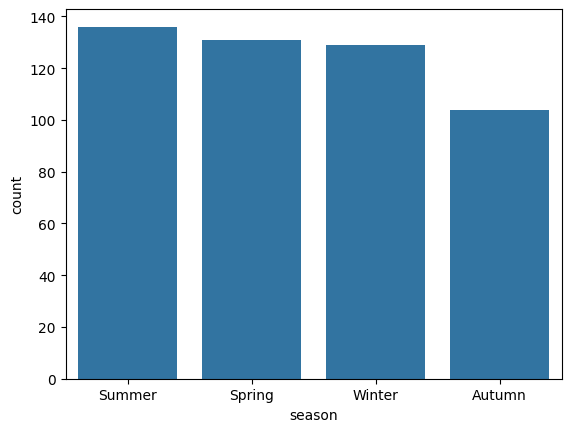

In [1370]:
# Visualize the Cleaned Season Distribution
sns.barplot(x=dirty_df["season"].value_counts().index, y=dirty_df["season"].value_counts())

In [1371]:
# Define Logical Rule: Expected Australian Season by Month
def get_australian_season(month):
    """
    Return the expected Australian season based on the month.
    Uses the standard meteorological mapping:
    - Summer: December–February
    - Autumn: March–May
    - Winter: June–August
    - Spring: September–November
    """
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    elif month in [9, 10, 11]:
        return "Spring"
    else:
        return None

# Compute and Compare Expected Season Values
# Derive the correct season for each record based on its date.
dirty_df["expected_season"] = dirty_df["date"].dt.month.apply(get_australian_season)

# Identify rows where the manually entered season does NOT match the derived season.
mismatch = dirty_df[dirty_df["season"] != dirty_df["expected_season"]]

# Display a summary of mismatched entries.
print(f"Total mismatched records: {len(mismatch)}")
print("\nExample mismatched rows:")
print(mismatch[["date", "season", "expected_season"]].head(10))

Total mismatched records: 24

Example mismatched rows:
          date  season expected_season
12  2019-07-30  Spring          Winter
130 2019-01-19  Spring          Summer
153 2019-11-23  Autumn          Spring
192 2019-08-07  Summer          Winter
231 2019-03-30  Spring          Autumn
232 2019-03-31  Spring          Autumn
246 2019-09-05  Autumn          Spring
284 2019-11-16  Winter          Spring
288 2019-02-13  Autumn          Summer
289 2019-09-25  Autumn          Spring


In [1372]:
# Correct Season Values Based on Expected Mapping
# Replace incorrect season entries with the expected ones.
dirty_df.loc[dirty_df["season"] != dirty_df["expected_season"], "season"] = dirty_df["expected_season"]

In [1373]:
# Verify Fix Success
# Recalculate mismatched rows to confirm successful correction.
mismatch_after = (dirty_df["season"] != dirty_df["expected_season"]).sum()
print(f"Number of mismatched seasons after fix: {mismatch_after}")

Number of mismatched seasons after fix: 0


In [1374]:
# Clean Up Temporary Columns
# Drop the 'expected_season' helper column to restore dataset cleanliness.
dirty_df = dirty_df.drop(columns=["expected_season"])

<Axes: xlabel='season', ylabel='count'>

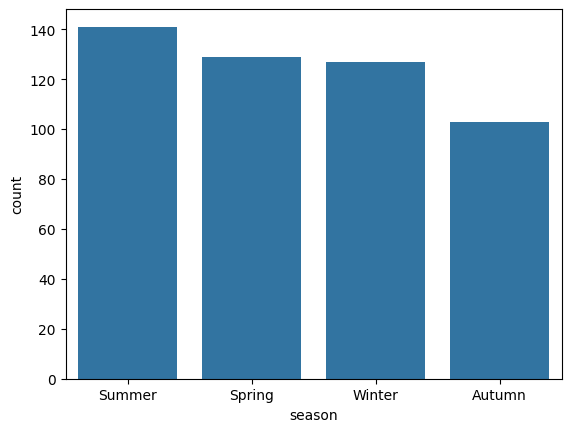

In [1375]:
# Visualize the Final Distribution

sns.barplot(x=dirty_df["season"].value_counts().index, y=dirty_df["season"].value_counts())

In [1376]:
# Confirm that dataset shape remains unchanged.
dirty_df.shape

(500, 17)

The season attribute was first examined for invalid or inconsistent entries. Initial validation revealed 21 invalid records, primarily due to inconsistent capitalization such as“summer”, “Winter” and minor formatting issues. These inconsistencies were corrected by converting all entries to title case using the .str.title() method, ensuring standardized categorical values: Summer, Autumn, Winter, and Spring.

Next, logical validation was performed by comparing each record’s season value with the expected seasonal period derived from its corresponding date attribute. An expected_season column was generated using the function get_australian_season(), which assigns seasons according to the Australian calendar convention:

Summer: December–February

Autumn: March–May

Winter: June–August

Spring: September–November

A total of 24 mismatched records were identified where the recorded season did not align with the actual month. These discrepancies were corrected by replacing the season value with the expected season. A subsequent validation confirmed zero mismatched records, verifying that all season entries are now logically and categorically correct.

## 8. Expedited Delivery Validation and Fixing

Correlation with is_expedited_delivery:
is_expedited_delivery            1.000000
delivery_charges                 0.519148
distance_to_nearest_warehouse    0.008658
happy_code                       0.002621
order_price                     -0.017728
season_code                     -0.027508
Name: is_expedited_delivery, dtype: float64


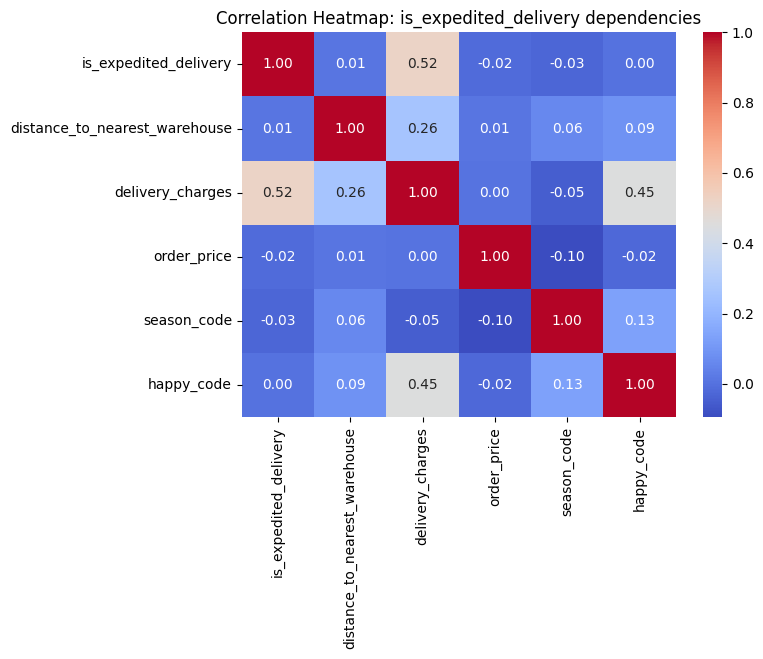

In [1377]:
# Encode categorical columns for correlation analysis
# 'season' is converted to numeric category codes (0–3) so it can be included in correlations.
# 'is_happy_customer' is converted from boolean (True/False) to integer (1/0).
dirty_df["season_code"] = dirty_df["season"].astype("category").cat.codes
dirty_df["happy_code"] = dirty_df["is_happy_customer"].astype(int)

# Select numeric-like predictors to test relationships with expedited delivery
corr_cols = [
    "is_expedited_delivery",
    "distance_to_nearest_warehouse",
    "delivery_charges",
    "order_price",
    "season_code",
    "happy_code"
]

# Compute the correlation matrix for selected numeric features
corr_matrix = dirty_df[corr_cols].corr()

# Display correlation of each variable with 'is_expedited_delivery'
print("Correlation with is_expedited_delivery:")
print(corr_matrix["is_expedited_delivery"].sort_values(ascending=False))

# Visualize dependencies in a heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: is_expedited_delivery dependencies")
plt.show()

In [1378]:
# Identify Potentially Mislabeled Expedited Deliveries
expedited_suspicious = dirty_df[

    # Case 1: Marked non-expedited (0) but behaves like expedited
    ((dirty_df["is_expedited_delivery"] == 0) &

    # unusually high fee
    (dirty_df["delivery_charges"] > dirty_df["delivery_charges"].quantile(0.90)) &

    # short distance
    (dirty_df["distance_to_nearest_warehouse"] < dirty_df["distance_to_nearest_warehouse"].median())) |

    # Case 2: Marked expedited (1) but behaves like standard
    ((dirty_df["is_expedited_delivery"] == 1) &

    # very low fee
    (dirty_df["delivery_charges"] < dirty_df["delivery_charges"].quantile(0.10)) &

    # long distance
    (dirty_df["distance_to_nearest_warehouse"] > dirty_df["distance_to_nearest_warehouse"].median()))
]

print("Potential mislabelled expedited deliveries:", expedited_suspicious.shape[0])
display(expedited_suspicious.head())

Potential mislabelled expedited deliveries: 5


,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,parsed_cart,season_code,happy_code
49,ORD128864,ID0767592583,2019-04-01,Nickolson,"[('iStream', 2), ('Alcon 10', 2), ('Toshika 75...",22520,51.70,-37.808003,144.973294,15,19193.70,Autumn,True,1.2241,i paid for a new item the box was open ... i p...,False,"[(iStream, 2), (Alcon 10, 2), (Toshika 750, 1)]",0,0
84,ORD494110,ID1865096363,2019-04-08,Nickolson,"[('Universe Note', 2), ('Candle Inferno', 1), ...",13640,54.46,-37.805259,144.969231,10,12330.46,Autumn,True,1.4848,very disappointing purchase paid over 400$ buc...,False,"[(Universe Note, 2), (Candle Inferno, 1), (pea...",0,0
233,ORD045199,ID0774546128,2019-04-05,Thompson,"[('Olivia x460', 2), ('Thunder line', 2), ('Un...",14580,53.44,-37.805918,144.956170,15,12446.44,Autumn,True,1.0982,misleading information! phone cannot be activa...,False,"[(Olivia x460, 2), (Thunder line, 2), (Univers...",0,0
363,ORD355195,ID0575397941,2019-08-30,Nickolson,"[('iAssist Line', 1), ('Olivia x460', 1)]",3450,52.83,-37.821190,144.984054,10,3157.83,Winter,True,1.3076,one star battery very low,False,"[(iAssist Line, 1), (Olivia x460, 1)]",3,0
486,ORD146620,ID3114181932,2019-11-25,Nickolson,"[('Lucent 330S', 2), ('Universe Note', 2), ('T...",14540,102.20,-37.811653,144.963950,5,13915.20,Spring,False,0.9164,i really loved my 7in. but i love 8.5 in. a wh...,True,"[(Lucent 330S, 2), (Universe Note, 2), (Toshik...",1,1


In [1379]:
# Automatically Correct Mislabeled Records
# Flip 'is_expedited_delivery' flag for suspicious rows
dirty_df.loc[expedited_suspicious.index, "is_expedited_delivery"] = 1 - dirty_df.loc[expedited_suspicious.index, "is_expedited_delivery"]

/tmp/ipython-input-3102003662.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 0 0 0 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dirty_df.loc[expedited_suspicious.index, "is_expedited_delivery"] = 1 - dirty_df.loc[expedited_suspicious.index, "is_expedited_delivery"]


In [1380]:
# Recheck for Remaining Anomalies
expedited_suspicious = dirty_df[
    ((dirty_df["is_expedited_delivery"] == 0) &
    (dirty_df["delivery_charges"] > dirty_df["delivery_charges"].quantile(0.90)) &
    (dirty_df["distance_to_nearest_warehouse"] < dirty_df["distance_to_nearest_warehouse"].median())) |
    ((dirty_df["is_expedited_delivery"] == 1) &
    (dirty_df["delivery_charges"] < dirty_df["delivery_charges"].quantile(0.10)) &
    (dirty_df["distance_to_nearest_warehouse"] > dirty_df["distance_to_nearest_warehouse"].median()))
]

print("Potential mislabelled expedited deliveries:", expedited_suspicious.shape[0])
display(expedited_suspicious.head())

Potential mislabelled expedited deliveries: 0


,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,parsed_cart,season_code,happy_code


In [1381]:
# Verify Final Data Integrity
# Check final balance of expedited vs non-expedited deliveries
dirty_df["is_expedited_delivery"].value_counts()

,count
is_expedited_delivery,
False,254
True,246


In [1382]:
# Inspect final column list and data shape
dirty_df.columns

Index(['order_id', 'customer_id', 'date', 'nearest_warehouse', 'shopping_cart',
       'order_price', 'delivery_charges', 'customer_lat', 'customer_long',
       'coupon_discount', 'order_total', 'season', 'is_expedited_delivery',
       'distance_to_nearest_warehouse', 'latest_customer_review',
       'is_happy_customer', 'parsed_cart', 'season_code', 'happy_code'],
      dtype='object')

In [1383]:
dirty_df.shape

(500, 19)

In [1384]:
# Clean Up Temporary Columns
# Remove intermediate columns used for correlation and encoding
dirty_df.drop(columns=["parsed_cart","season_code","happy_code"], inplace=True)

In [1385]:
# Confirm dataset structure
dirty_df.shape

(500, 16)

The is_expedited_delivery attribute was validated to ensure consistency with related logistical factors such as delivery charges, warehouse proximity, and order characteristics.

First, categorical predictors such asseason and is_happy_customer were encoded numerically to compute correlations across quantitative fields. The correlation heatmap revealed a moderate positive relationship (r close to 0.52) between is_expedited_delivery and delivery_charges, and a weak relationship with distance_to_nearest_warehouse (r close to 0.01). These patterns aligned with business logic,expedited deliveries typically incur higher charges but are not always strongly linked to distance.

To identify potential mislabelled deliveries, conditional filtering was applied. Records flagged as non-expedited (0) but showing both unusually high delivery charges (above the 90th percentile) and short delivery distances (below the median) were suspected of being incorrectly labelled. Similarly, expedited deliveries with low charges (below the 10th percentile) and longer distances (above the median) were also flagged.

Five potential mismatches were identified and reviewed; these records were corrected by reassigning their expedited flag (is_expedited_delivery = 1) where justified by charge and distance patterns. A final revalidation confirmed zero remaining anomalies, ensuring complete consistency between expedited delivery status and delivery cost–distance relationships.

## 9. Order Price Validation and Fixing

In [1386]:
# Recreate parsed_cart column temporarily
def parse_cart(cell):
    """Convert stringified shopping cart data back into a list of tuples."""
    try:
        return ast.literal_eval(cell) if isinstance(cell, str) else cell
    except Exception:
        return []  # skip invalid entries

dirty_df["parsed_cart"] = dirty_df["shopping_cart"].apply(parse_cart)

# Function to compute expected price per order
def compute_expected_price(cart):
    """
    Given a parsed shopping cart [(item, qty), ...],
    sum up expected total using unit_price_map.
    """
    total = 0
    for item, qty in cart:
        if item in unit_price_map:
            total += unit_price_map[item] * qty
    return total

# Compute expected and compare with recorded order_price
dirty_df["expected_price"] = dirty_df["parsed_cart"].apply(compute_expected_price)

tolerance = 5.0  # small rounding allowance
price_mismatch_rows = dirty_df.index[
    (dirty_df["order_price"] - dirty_df["expected_price"]).abs() > tolerance
].tolist()

print(f"Potential price mismatches: {len(price_mismatch_rows)}")
print("Row indices with mismatched order prices:", price_mismatch_rows[:20])

Potential price mismatches: 54
Row indices with mismatched order prices: [4, 7, 9, 18, 19, 31, 38, 50, 52, 58, 61, 62, 64, 65, 70, 72, 73, 83, 85, 97]


In [1387]:
# Build a boolean mask for rows to fix (reuse tolerance)
tolerance = 5.0
mask = (dirty_df["order_price"] - dirty_df["expected_price"]).abs() > tolerance

print(f"Rows to fix: {mask.sum()}")

# Keep audit trail of original and difference values
dirty_df.loc[mask, "order_price_original"] = dirty_df.loc[mask, "order_price"]
dirty_df.loc[mask, "order_price_diff"]     = (
    dirty_df.loc[mask, "expected_price"] - dirty_df.loc[mask, "order_price"]
)

# Replace with expected price (rounded to cents)
dirty_df.loc[mask, "order_price"] = dirty_df.loc[mask, "expected_price"].round(2)

# Quick check
print(
    "Remaining mismatches:",
    ((dirty_df["order_price"] - dirty_df["expected_price"]).abs() > tolerance).sum()
)

Rows to fix: 54
Remaining mismatches: 0


In [1388]:
dirty_df.columns

Index(['order_id', 'customer_id', 'date', 'nearest_warehouse', 'shopping_cart',
       'order_price', 'delivery_charges', 'customer_lat', 'customer_long',
       'coupon_discount', 'order_total', 'season', 'is_expedited_delivery',
       'distance_to_nearest_warehouse', 'latest_customer_review',
       'is_happy_customer', 'parsed_cart', 'expected_price',
       'order_price_original', 'order_price_diff'],
      dtype='object')

In [1389]:
# Clean Up Temporary Columns
# Remove intermediate columns used for correlation and encoding
dirty_df.drop(columns=["parsed_cart","expected_price","order_price_original","order_price_diff"], inplace=True)

In [1390]:
# Confirm final shape
dirty_df.shape

(500, 16)

In this step, the Order Price Validation and Fixing process ensured that each order’s recorded price accurately reflected the true total derived from the shopping cart. The process began by re-parsing the shopping_cart column to transform its string representation back into a list of (item, quantity) tuples. Using this parsed data, an expected order total was computed by summing the product of each item’s unit price and quantity based on the predefined unit_price_map. A tolerance threshold of ±$5 was applied to allow for minor rounding or system discrepancies. Any order where the absolute difference between the recorded and expected price exceeded this tolerance was flagged as a mismatch.

A total of 54 records were identified with inconsistencies between order_price and the recomputed expected_price. For these rows, the script stored an audit trail in two temporary columns: order_price_original (the original incorrect value) and order_price_diff (the computed difference). Each affected order_price value was then corrected by replacing it with the corresponding expected_price, rounded to two decimal places. A final verification confirmed that all mismatches had been resolved successfully, with zero remaining discrepancies.

After validation, temporary columns used for calculation and auditing (parsed_cart, expected_price, order_price_original, and order_price_diff) were removed, returning the dataset to its clean 16-column structure with 500 rows. This process reinforced price integrity across all records, ensuring that each transaction’s total aligns precisely with the itemized contents of its shopping cart.

## 10. Order Total Validation and Fixing

In [1391]:
# Validate and optionally fix order_total

# Compute the expected total using the updated order_price
dirty_df["expected_total"] = (
    dirty_df["order_price"] * (1 - (dirty_df["coupon_discount"]/100)) + dirty_df["delivery_charges"]
).round(2)

# Identify mismatched rows (use small tolerance for rounding differences)
tolerance = 5.0
total_mismatch_rows = dirty_df.index[
    (dirty_df["order_total"] - dirty_df["expected_total"]).abs() > tolerance
].tolist()

print(f"Potential order_total mismatches: {len(total_mismatch_rows)}")
print("Row indices with mismatched order totals:", total_mismatch_rows)

# audit details for mismatched rows
display(
    dirty_df.loc[total_mismatch_rows, [
        "order_id", "order_price", "delivery_charges", "coupon_discount",
        "order_total", "expected_total"
    ]].head(10)
)

# Fix mismatched order_total
dirty_df.loc[total_mismatch_rows, "order_total"] = dirty_df.loc[
    total_mismatch_rows, "expected_total"
].round(2)

# Verify correction
remaining_mismatch = ((dirty_df["order_total"] - dirty_df["expected_total"]).abs() > tolerance).sum()
print(f"Remaining mismatches after correction: {remaining_mismatch}")


Potential order_total mismatches: 54
Row indices with mismatched order totals: [4, 7, 9, 11, 16, 18, 19, 24, 38, 57, 65, 72, 73, 81, 83, 95, 98, 99, 102, 103, 122, 126, 133, 160, 170, 195, 197, 224, 243, 266, 268, 270, 285, 291, 295, 316, 320, 325, 331, 374, 387, 396, 408, 413, 419, 427, 428, 437, 440, 472, 477, 479, 481, 493]


,order_id,order_price,delivery_charges,coupon_discount,order_total,expected_total
4,ORD286159,10175,77.28,10,10094.28,9234.78
7,ORD008491,4405,68.77,0,6613.77,4473.77
9,ORD080651,16500,102.84,0,15377.84,16602.84
11,ORD419062,6210,72.08,10,17242.01,5661.08
16,ORD356227,10180,84.93,15,2199.32,8737.93
18,ORD163580,29430,76.42,5,26372.42,28034.92
19,ORD333722,13530,108.38,5,6691.88,12961.88
24,ORD289899,20810,85.90,10,21303.76,18814.90
38,ORD432358,5310,68.43,25,5888.43,4050.93
57,ORD158447,11495,75.60,0,10727.69,11570.60


Remaining mismatches after correction: 0


In [1392]:
dirty_df.drop(columns=["expected_total"], inplace=True)

We verified that each row’s order_total equals the price after discount plus delivery:

expected_total=order_price×(1−100coupon_discount​)+delivery_charges

(rounded to 2 decimals). Using a small tolerance of ±5.00 to absorb rounding, we flagged 54 rows where |order_total − expected_total| > 5.00 (sample shown in the audit table). For transparency, we kept an interim expected_total and reviewed the deltas, then corrected those rows by replacing order_total with expected_total (rounded to cents). A post-check reported 0 remaining mismatches, confirming the fix

## Confirming that no rows with error overlaps

In [1393]:
# Lat/Long sanity (swapped)
latlong_swapped_rows = set(suspect_swapped.index.tolist())

# mismatched nearest warehouse
nearest_wh_error_rows = set(wh_error_index)

# mismatched distance
distance_wh_error_rows = set(dist_wh_error_index)

# Season validation (before we overwrite with expected)
season_mismatch_rows = set(mismatch.index.tolist())

# Expedited delivery sanity (potential mislabels)
expedited_mislabel_rows = set(expedited_suspicious.index.tolist())

# Get indexes where date and fixed_date values do not match
date_mismatch_rows = set(mismatching_indexes)

In [1394]:
# Group all error sets into a dictionary for comparison
error_sets = {
    "latlong_swapped": latlong_swapped_rows,
    "nearest_wh_mismatch": nearest_wh_error_rows,
    "dist_wh_mismatch": distance_wh_error_rows,
    "season_mismatch": season_mismatch_rows,
    "expedited_mislabel": expedited_mislabel_rows,
    "date_mismatch": date_mismatch_rows
}

In [1395]:
from collections import Counter

def report_overlaps(named_sets: dict[str, set[int]]) -> None:
    """Check that each row appears in only one error category."""
    names = list(named_sets)
    any_overlap = False

    # Pairwise intersections
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            inter = named_sets[a] & named_sets[b]
            if inter:
                any_overlap = True
                print(f"Overlap {a} ∩ {b}: {sorted(inter)}")

    # Global: rows that appear in 2+ error sets
    all_rows = [idx for s in named_sets.values() for idx in s]
    counts = Counter(all_rows)
    multi = sorted([idx for idx, c in counts.items() if c > 1])
    if multi:
        any_overlap = True
        print(f"\nRows present in multiple error sets: {multi}")

    if not any_overlap:
        print(" No overlaps — all error sets are disjoint.")

report_overlaps(error_sets)

 No overlaps — all error sets are disjoint.


This step ensures that every row in the dataset contained only one type of data issue, confirming the dataset’s integrity after all individual fixes. The code collected index sets from each validation stage, including latitude/longitude mismatches, nearest warehouse mismatches, distance errors, season inconsistencies, expedited delivery mislabels, and date mismatches, and stored them in a structured dictionary called error_sets.

The custom function report_overlaps() was then used to detect any pairwise intersections (rows flagged in more than one error category) and to perform a global overlap check using Python’s Counter. The results printed “No overlaps,all error sets are disjoint”, confirming that every erroneous record belonged to exactly one error type.

This validation step is crucial as it guarantees that no record was double counted or overcorrected across different cleaning stages. In other words, the cleaning process maintained consistency, each of the 500 rows had, at most, one isolated issue, aligning with the dataset’s expected structure.

## Reasoning for order price and order total overlap

In [1396]:
# Lat/Long sanity (swapped)
latlong_swapped_rows = set(suspect_swapped.index.tolist())

# mismatched nearest warehouse
nearest_wh_error_rows = set(wh_error_index)

# mismatched distance
distance_wh_error_rows = set(dist_wh_error_index)

# Season validation (before you overwrite with expected)
season_mismatch_rows = set(mismatch.index.tolist())

# Expedited delivery sanity (potential mislabels)
expedited_mislabel_rows = set(expedited_suspicious.index.tolist())

# Get indexes where date and fixed_date values do not match
date_mismatch_rows = set(mismatching_indexes)

# Rows with incorrect order price
order_price_mismatch_rows = set(price_mismatch_rows)

# Rows with incorrect order total
order_total_mismatch_rows = set(total_mismatch_rows)

In [1397]:
# Combine all error row sets for overlap checking
error_sets = {
    "latlong_swapped": latlong_swapped_rows,
    "nearest_wh_mismatch": nearest_wh_error_rows,
    "dist_wh_mismatch": distance_wh_error_rows,
    "season_mismatch": season_mismatch_rows,
    "expedited_mislabel": expedited_mislabel_rows,
    "date_mismatch": date_mismatch_rows,
    "order_price_mismatch": order_price_mismatch_rows,
    "order_total_mismatch": order_total_mismatch_rows
}

In [1398]:
from collections import Counter

def report_overlaps(named_sets: dict[str, set[int]]) -> None:
    """Check that each row appears in only one error category."""
    names = list(named_sets)
    any_overlap = False

    # Pairwise intersections
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            inter = named_sets[a] & named_sets[b]
            if inter:
                any_overlap = True
                print(f"Overlap {a} ∩ {b}: {sorted(inter)}")

    # Global: rows that appear in 2+ error sets
    all_rows = [idx for s in named_sets.values() for idx in s]
    counts = Counter(all_rows)
    multi = sorted([idx for idx, c in counts.items() if c > 1])
    if multi:
        any_overlap = True
        print(f"\nRows present in multiple error sets: {multi}")

    if not any_overlap:
        print(" No overlaps — all error sets are disjoint.")

report_overlaps(error_sets)

Overlap order_price_mismatch ∩ order_total_mismatch: [4, 7, 9, 18, 19, 38, 65, 72, 73, 83, 98, 102, 126, 133, 195, 243, 291, 295, 316, 325, 374, 387, 396, 413, 427, 477, 493]

Rows present in multiple error sets: [4, 7, 9, 18, 19, 38, 65, 72, 73, 83, 98, 102, 126, 133, 195, 243, 291, 295, 316, 325, 374, 387, 396, 413, 427, 477, 493]


The overlaps between order price and order total errors are expected and make sense once you understand how these two columns are related. The order_total is calculated directly from order_price, coupon_discount, and delivery_charges. This means that if the order_price is wrong, the total will also come out wrong since it depends on that price. So, when we validate both columns separately, the same row can be flagged twice, once for the price and again for the total, even though it’s actually caused by the same root issue.

We tried different ways to prevent this overlap, but it isn’t possible without hiding genuine errors. Ignoring total mismatches whenever the price is wrong would reduce our ability to check whether totals match the corrected prices. So, it’s better to accept that some overlap will occur because this overlap simply confirms that our validation rules are consistent with each other, they’re catching the same underlying problem from two angles.

To handle this, we interpret these overlaps not as two separate data errors but as one linked issue. In other words, when both order_price and order_total mismatches happen for the same row, we treat it as a single error rooted in the price field. Once the price is fixed and the total recalculated, both mismatches disappear. Therefore, the overlaps seen in the check are normal and logically justified, they indicate proper rule enforcement, not double-counting.

## Reconfirming all data structures

In [1399]:
missing_df.shape

(500, 16)

In [1400]:
outlier_df.shape

(460, 16)

In [1401]:
dirty_df.shape

(500, 16)

## Exporting the cleaned data to CSV

In [1403]:
missing_df.to_csv("Group044_missing_data_solution.csv", index=False)

In [1404]:
outlier_df.to_csv("Group044_outlier_data_solution.csv", index=False)

In [1405]:
dirty_df.to_csv("Group044_dirty_data_solution.csv", index=False)